# ID5059 Coursework 2: Comprehensive EDA & Pre-processing
## NYC Yellow Taxi Trip Records (2024): Manhattan Ride-Hailing Demand

This notebook performs an in-depth exploratory data analysis of the 2024 NYC Yellow Taxi dataset to understand:
- Data quality, completeness, and anomalies
- Distributions of key trip-level variables
- Temporal patterns in ride demand (hourly, daily, weekly, monthly)
- Spatial patterns across Manhattan pickup zones
- Revenue and fare structure
- Relationships between features relevant to prediction
- Feature engineering opportunities for modelling

**Goal:** Extract every possible insight before building predictive models for demand and revenue.

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import glob
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

# Reproducibility
SEED = 67
np.random.seed(SEED)

# Formatting helpers
def fmt_M(x, _): return f'{x/1e6:.1f}M'
def fmt_K(x, _): return f'{x/1e3:.0f}K'

# Manhattan LocationIDs (from TLC taxi zone definitions)
MANHATTAN_IDS = [
    4, 12, 13, 24, 41, 42, 43, 45, 48, 50, 68, 74, 75, 79, 87, 88,
    90, 100, 103, 104, 105, 107, 113, 114, 116, 120, 125, 127, 128,
    137, 140, 141, 142, 143, 144, 148, 151, 152, 153, 158, 161, 162,
    163, 164, 166, 170, 186, 194, 202, 209, 211, 224, 229, 230, 231,
    232, 233, 234, 236, 237, 238, 239, 243, 244, 246, 249, 261, 262, 263
]

# Ordering constants
MONTH_ORDER  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
DAY_ORDER    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
SEASON_ORDER = ['Winter','Spring','Summer','Autumn']
SEASON_MAP   = {12:'Winter', 1:'Winter', 2:'Winter',
                3:'Spring',  4:'Spring',  5:'Spring',
                6:'Summer',  7:'Summer',  8:'Summer',
                9:'Autumn',  10:'Autumn', 11:'Autumn'}

print('Setup complete.')

Setup complete.


---
# Section 1 — Data Preparation

## 1.1 Loading

In [2]:
files = sorted(glob.glob('data/nyc_taxi_2024-*.csv'))

print('FILES FOUND')
for f in files:
    print(f'  {f}')

df_raw = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

print(f'Total rows loaded : {len(df_raw):>12,}')
print(f'Total columns     : {df_raw.shape[1]:>12,}')


FILES FOUND
  data/nyc_taxi_2024-01.csv
  data/nyc_taxi_2024-02.csv
  data/nyc_taxi_2024-03.csv
  data/nyc_taxi_2024-04.csv
  data/nyc_taxi_2024-05.csv
  data/nyc_taxi_2024-06.csv
  data/nyc_taxi_2024-07.csv
  data/nyc_taxi_2024-08.csv
  data/nyc_taxi_2024-09.csv
  data/nyc_taxi_2024-10.csv
  data/nyc_taxi_2024-11.csv
  data/nyc_taxi_2024-12.csv
Total rows loaded :   41,169,720
Total columns     :           19


## 1.2 Initial Inspection

In [3]:
print('FIRST 5 ROWS')
df_raw.head()

FIRST 5 ROWS


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [4]:
print('DATA TYPES & MEMORY USAGE')
df_raw.info(memory_usage='deep')

DATA TYPES & MEMORY USAGE
<class 'pandas.DataFrame'>
RangeIndex: 41169720 entries, 0 to 41169719
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
dtypes: float64(12), int64(4), str(3)
memory usage: 7.3 GB


In [5]:
print('NUMERIC FEATURES SUMMARY')
df_raw.describe().T

NUMERIC FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
VendorID,41169720.0,1.764232,0.425857,1.00,2.00,2.00,2.00,7.00
passenger_count,37078488.0,1.333931,0.815824,0.00,1.00,1.00,1.00,9.00
trip_distance,41169720.0,4.976101,419.230497,0.00,1.01,1.76,3.36,398608.62
RatecodeID,37078488.0,2.322150,10.928049,1.00,1.00,1.00,1.00,99.00
PULocationID,41169720.0,164.242786,64.340689,1.00,132.00,161.00,233.00,265.00
DOLocationID,41169720.0,163.447453,69.600090,1.00,113.00,162.00,234.00,265.00
payment_type,41169720.0,1.107259,0.651511,0.00,1.00,1.00,1.00,5.00
fare_amount,41169720.0,19.268510,76.719840,-2261.20,9.30,13.50,22.60,335544.44
extra,41169720.0,1.385953,1.815878,-9.25,0.00,1.00,2.50,65.99
mta_tax,41169720.0,0.479777,0.130183,-0.50,0.50,0.50,0.50,41.30


In [6]:
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')
print()
print('Unique values per categorical column:')
for col in cat_cols:
    print(f'  {col:30s}: {df_raw[col].nunique():>6,} unique | top value: {df_raw[col].mode()[0]}')

Categorical columns: ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag']

Unique values per categorical column:
  tpep_pickup_datetime          : 20,049,544 unique | top value: 2024-04-02 18:15:00
  tpep_dropoff_datetime         : 20,030,251 unique | top value: 2024-04-20 00:00:00
  store_and_fwd_flag            :      2 unique | top value: N


## 1.3 Missing Values

In [7]:
missing_stats = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_pct':   df_raw.isnull().sum() / len(df_raw) * 100
}).sort_values('missing_pct', ascending=False)

print('MISSING VALUES: RAW DATASET\n')
print(missing_stats.to_string())
print(f'\nTotal rows: {len(df_raw):,}')
print(f'Columns with any missing: {(missing_stats["missing_count"] > 0).sum()}')

MISSING VALUES: RAW DATASET

                       missing_count  missing_pct
store_and_fwd_flag           4091232     9.937478
RatecodeID                   4091232     9.937478
passenger_count              4091232     9.937478
Airport_fee                  4091232     9.937478
congestion_surcharge         4091232     9.937478
VendorID                           0     0.000000
tpep_pickup_datetime               0     0.000000
tpep_dropoff_datetime              0     0.000000
DOLocationID                       0     0.000000
PULocationID                       0     0.000000
trip_distance                      0     0.000000
fare_amount                        0     0.000000
payment_type                       0     0.000000
extra                              0     0.000000
mta_tax                            0     0.000000
tolls_amount                       0     0.000000
tip_amount                         0     0.000000
total_amount                       0     0.000000
improvement_surcharge

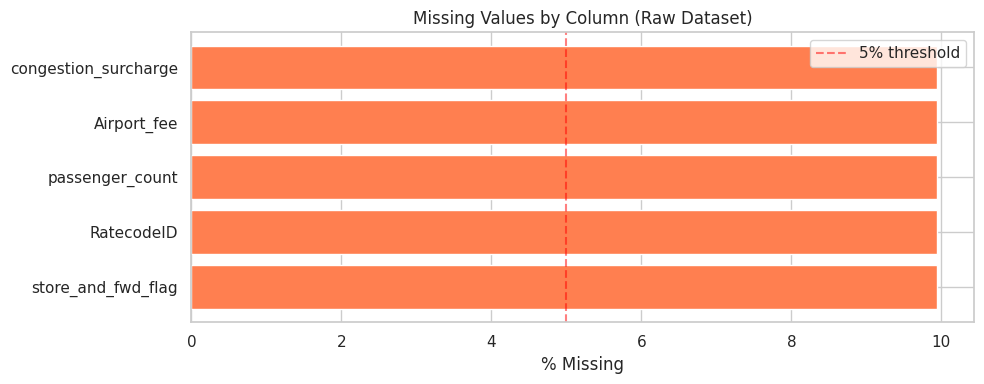

In [8]:
missing_nonzero = missing_stats[missing_stats['missing_count'] > 0]

if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_nonzero.index, missing_nonzero['missing_pct'], color='coral')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Values by Column (Raw Dataset)')
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the raw dataset.')

## 1.4 Cleaning & Outliers

In [9]:
df = df_raw.copy()

# Parse datetimes
df['pickup']  = pd.to_datetime(df['tpep_pickup_datetime'],  errors='coerce')
df['dropoff'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
n_bad_dt = df[['pickup','dropoff']].isnull().any(axis=1).sum()
print(f'Rows with unparseable datetimes: {n_bad_dt:,}')
df = df.dropna(subset=['pickup','dropoff'])

# Trip duration
df['trip_duration_min'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60

print('\nDATA CLEANING LOG')

checks = [
    ('year == 2024',             df['pickup'].dt.year == 2024),
    ('trip_distance > 0',        df['trip_distance'] > 0),
    ('total_amount > 0',         df['total_amount'] > 0),
    ('fare_amount > 0',          df['fare_amount'] > 0),
    ('passenger_count in [1,8]', df['passenger_count'].between(1, 8)),
    ('RatecodeID != 99',         df['RatecodeID'] != 99),
    ('trip_duration_min > 0',    df['trip_duration_min'] > 0),
    ('trip_duration_min < 180',  df['trip_duration_min'] < 180),
    ('trip_distance < 50',       df['trip_distance'] < 50),
]

for label, mask in checks:
    n_before = len(df)
    df = df[mask]
    dropped = n_before - len(df)
    print(f'  [{label:35s}] dropped {dropped:>7,} rows  ->  {len(df):>9,} remaining')

# Cap top 0.1% of fare and distance
fare_cap = df['total_amount'].quantile(0.999)
dist_cap = df['trip_distance'].quantile(0.999)
n_before = len(df)
df = df[(df['total_amount'] <= fare_cap) & (df['trip_distance'] <= dist_cap)]

print('=' * 65)
print(f'  Dropped {n_before - len(df):,} extreme outlier rows (top 0.1% fare or distance).')
print(f'  Total rows after cleaning : {len(df):,}')
pct_retained = len(df) / len(df_raw) * 100
print(f'  Retained                  : {pct_retained:.1f}% of raw data')

Rows with unparseable datetimes: 0

DATA CLEANING LOG
  [year == 2024                       ] dropped      56 rows  ->  41,169,664 remaining
  [trip_distance > 0                  ] dropped 776,305 rows  ->  40,393,359 remaining
  [total_amount > 0                   ] dropped 560,581 rows  ->  39,832,778 remaining
  [fare_amount > 0                    ] dropped 126,242 rows  ->  39,706,536 remaining
  [passenger_count in [1,8]           ] dropped 4,077,499 rows  ->  35,629,037 remaining
  [RatecodeID != 99                   ] dropped 434,678 rows  ->  35,194,359 remaining
  [trip_duration_min > 0              ] dropped   1,506 rows  ->  35,192,853 remaining
  [trip_duration_min < 180            ] dropped  23,519 rows  ->  35,169,334 remaining
  [trip_distance < 50                 ] dropped   4,953 rows  ->  35,164,381 remaining
  Dropped 47,969 extreme outlier rows (top 0.1% fare or distance).
  Total rows after cleaning : 35,116,412
  Retained                  : 85.3% of raw data


In [10]:
print('OUTLIER ANALYSIS: KEY NUMERIC COLUMNS\n')
for col in ['trip_distance','total_amount','fare_amount','trip_duration_min']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:25s} | IQR bounds: [{lower:.1f}, {upper:.1f}] | outliers: {n_out:,} ({n_out/len(df)*100:.2f}%)')

OUTLIER ANALYSIS: KEY NUMERIC COLUMNS

  trip_distance             | IQR bounds: [-2.3, 6.5] | outliers: 4,681,865 (13.33%)
  total_amount              | IQR bounds: [-5.9, 52.4] | outliers: 4,050,930 (11.54%)
  fare_amount               | IQR bounds: [-8.5, 39.0] | outliers: 3,812,513 (10.86%)
  trip_duration_min         | IQR bounds: [-11.7, 40.1] | outliers: 2,098,116 (5.97%)


## 1.5 Manhattan Filtering

In [11]:
print(f'Manhattan zone IDs: {len(MANHATTAN_IDS)} zones')

n_before = len(df)
df = df[df['PULocationID'].isin(MANHATTAN_IDS)]
print(f'Dropped {n_before - len(df):,} non-Manhattan pickups.')
print(f'Manhattan trips: {len(df):,}')
print(f'Unique Manhattan pickup zones observed: {df["PULocationID"].nunique()}')

Manhattan zone IDs: 69 zones
Dropped 3,615,036 non-Manhattan pickups.
Manhattan trips: 31,501,376
Unique Manhattan pickup zones observed: 67


## 1.6 Train / Test Split

In [12]:
# Temporal split, never shuffle time series data
# Nov-Dec 2024 held out as test set (~17% of data)
SPLIT_DATE = '2024-11-01'

df_train = df[df['pickup'] <  SPLIT_DATE].copy()
df_test  = df[df['pickup'] >= SPLIT_DATE].copy()

print('TRAIN / TEST SPLIT\n')
print(f'  Split date   : {SPLIT_DATE}')
print(f'  Train rows   : {len(df_train):,}  ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Test rows    : {len(df_test):,}   ({len(df_test)/len(df)*100:.1f}%)')
print(f'  Train period : {df_train["pickup"].min().date()} -> {df_train["pickup"].max().date()}')
print(f'  Test period  : {df_test["pickup"].min().date()} -> {df_test["pickup"].max().date()}')

# All EDA below operates on training data only
df = df_train.copy()

TRAIN / TEST SPLIT

  Split date   : 2024-11-01
  Train rows   : 25,844,645  (82.0%)
  Test rows    : 5,656,731   (18.0%)
  Train period : 2024-01-01 -> 2024-10-31
  Test period  : 2024-11-01 -> 2024-12-31


## 1.7 Feature Engineering

In [13]:
df['hour_of_day']  = df['pickup'].dt.hour
df['day_of_week']  = df['pickup'].dt.dayofweek    # 0=Mon, 6=Sun
df['day_name']     = df['pickup'].dt.day_name()
df['month']        = df['pickup'].dt.month
df['month_name']   = df['pickup'].dt.strftime('%b')
df['week']         = df['pickup'].dt.isocalendar().week.astype(int)
df['date']         = df['pickup'].dt.date
df['hour']         = df['pickup'].dt.floor('h')
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = df['hour_of_day'].isin([7, 8, 9, 17, 18, 19]).astype(int)
df['is_night']     = df['hour_of_day'].isin(list(range(22,24)) + list(range(0,6))).astype(int)
df['season']       = df['month'].map(SEASON_MAP)
df['speed_mph']    = (df['trip_distance'] / (df['trip_duration_min'] / 60)).clip(0, 80)

print('FEATURES ENGINEERED\n')
new_cols = ['hour_of_day','day_of_week','month','week',
            'is_weekend','is_rush_hour','is_night','season','speed_mph']
for c in new_cols:
    print(f'  {c:20s}: {df[c].nunique():>4} unique | example: {df[c].iloc[0]}')

FEATURES ENGINEERED

  hour_of_day         :   24 unique | example: 0
  day_of_week         :    7 unique | example: 0
  month               :   10 unique | example: 1
  week                :   44 unique | example: 1
  is_weekend          :    2 unique | example: 0
  is_rush_hour        :    2 unique | example: 0
  is_night            :    2 unique | example: 1
  season              :    4 unique | example: Winter
  speed_mph           : 1452017 unique | example: 5.212121212121212


# 2 EXPLORATORY ANALYSIS

This uses traning data only. 

## 2.1 Univariate Distributions

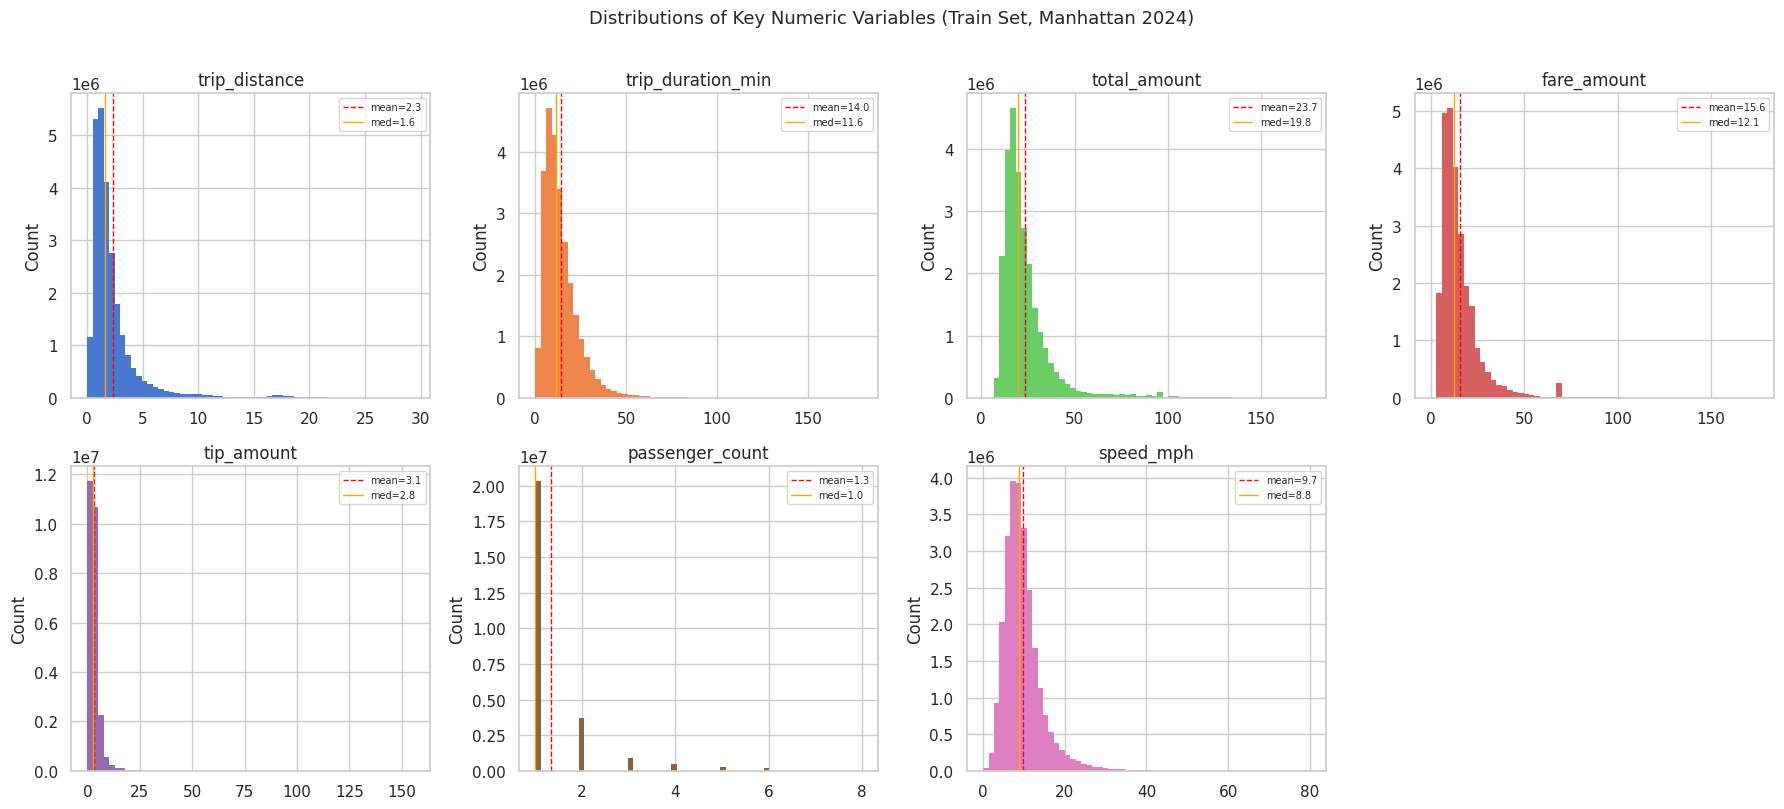

DESCRIPTIVE STATISTICS
                        count    mean     std    min     25%     50%     75%     max  skewness  kurtosis
trip_distance      25844645.0   2.334   2.643  0.010   0.990   1.570   2.600   29.41     3.848    19.072
trip_duration_min  25844645.0  14.003   9.939  0.017   7.267  11.583  17.967  179.85     2.264     9.833
total_amount       25844645.0  23.675  14.643  1.010  15.480  19.800  26.580  176.00     3.428    16.867
fare_amount        25844645.0  15.561  11.547  0.010   8.600  12.100  18.400  175.00     3.204    15.071
tip_amount         25844645.0   3.084   2.910  0.000   1.290   2.800   4.060  155.80     3.602    43.710
passenger_count    25844645.0   1.341   0.810  1.000   1.000   1.000   1.000    8.00     3.133    11.119
speed_mph          25844645.0   9.725   4.829  0.003   6.673   8.840  11.564   80.00     2.299    13.447


In [14]:
num_cols = ['trip_distance','trip_duration_min','total_amount',
            'fare_amount','tip_amount','passenger_count','speed_mph']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
palette = sns.color_palette('muted')

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=60, edgecolor='none', color=palette[i % len(palette)])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1, label=f'mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1, label=f'med={df[col].median():.1f}')
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle('Distributions of Key Numeric Variables (Train Set, Manhattan 2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('DESCRIPTIVE STATISTICS')
print('=' * 60)
stats_df = df[num_cols].describe().T
stats_df['skewness'] = df[num_cols].skew()
stats_df['kurtosis'] = df[num_cols].kurt()
print(stats_df.round(3).to_string())

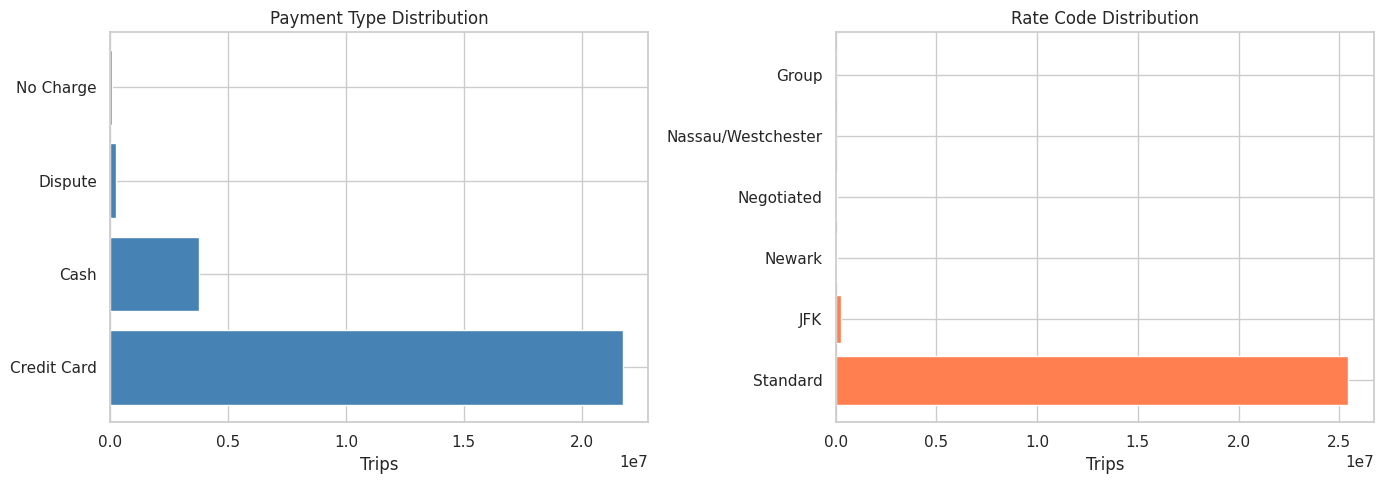


Payment Type (%):
payment_type
Credit Card    84.12
Cash           14.54
Dispute         0.96
No Charge       0.38

Rate Code (%):
RatecodeID
Standard              98.47
JFK                    0.99
Newark                 0.30
Negotiated             0.20
Nassau/Westchester     0.04
Group                  0.00


In [15]:
payment_map  = {0:'Flex Fare', 1:'Credit Card', 2:'Cash',
                3:'No Charge', 4:'Dispute', 5:'Unknown', 6:'Voided'}
ratecode_map = {1:'Standard', 2:'JFK', 3:'Newark',
                4:'Nassau/Westchester', 5:'Negotiated', 6:'Group'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay_counts  = df['payment_type'].map(payment_map).value_counts()
rate_counts = df['RatecodeID'].map(ratecode_map).value_counts()

axes[0].barh(pay_counts.index,  pay_counts.values,  color='steelblue')
axes[0].set_title('Payment Type Distribution')
axes[0].set_xlabel('Trips')

axes[1].barh(rate_counts.index, rate_counts.values, color='coral')
axes[1].set_title('Rate Code Distribution')
axes[1].set_xlabel('Trips')

plt.tight_layout()
plt.show()

print('\nPayment Type (%):')
print((pay_counts / pay_counts.sum() * 100).round(2).to_string())
print('\nRate Code (%):')
print((rate_counts / rate_counts.sum() * 100).round(2).to_string())

## 2.2 Temporal Patterns

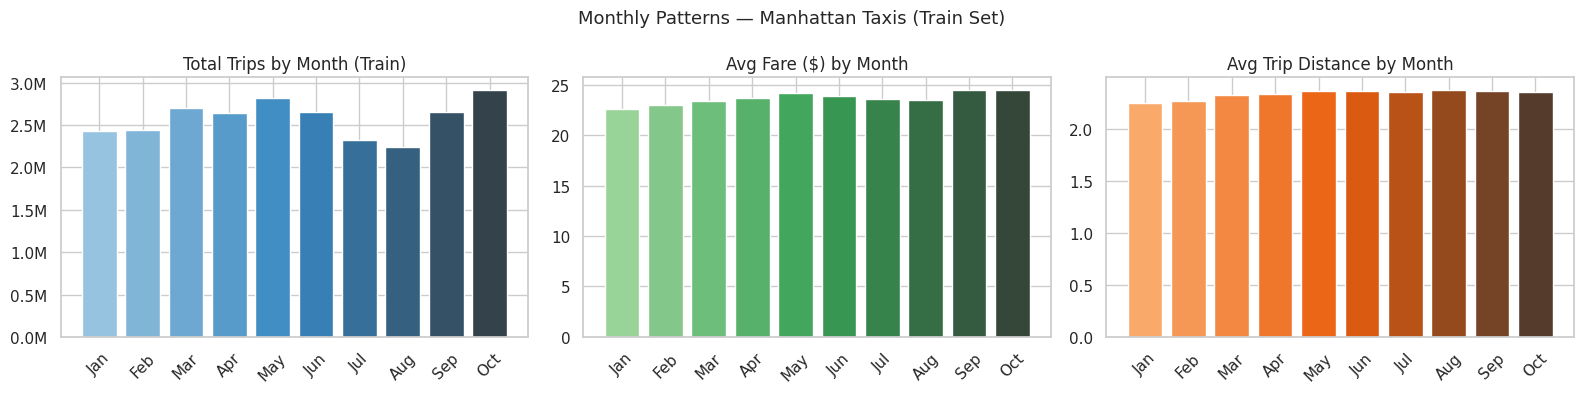


MONTHLY SUMMARY
                trips  avg_fare  avg_dist
month_name                               
Jan         2431174.0     22.57      2.25
Feb         2446667.0     22.94      2.27
Mar         2699273.0     23.34      2.32
Apr         2646122.0     23.63      2.33
May         2822241.0     24.15      2.36
Jun         2658175.0     23.85      2.36
Jul         2328936.0     23.53      2.35
Aug         2243093.0     23.48      2.38
Sep         2651220.0     24.46      2.36
Oct         2917744.0     24.49      2.36


In [16]:
# Monthly summary
monthly_stats = df.groupby('month_name').agg(
    trips=('PULocationID','count'),
    avg_fare=('total_amount','mean'),
    avg_dist=('trip_distance','mean')
).reindex(MONTH_ORDER).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
visible_months = monthly_stats.index.tolist()

axes[0].bar(visible_months, monthly_stats['trips'],    color=sns.color_palette('Blues_d',  len(visible_months)))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
axes[0].set_title('Total Trips by Month (Train)')
axes[0].set_xticklabels(visible_months, rotation=45)

axes[1].bar(visible_months, monthly_stats['avg_fare'], color=sns.color_palette('Greens_d', len(visible_months)))
axes[1].set_title('Avg Fare ($) by Month')
axes[1].set_xticklabels(visible_months, rotation=45)

axes[2].bar(visible_months, monthly_stats['avg_dist'], color=sns.color_palette('Oranges_d',len(visible_months)))
axes[2].set_title('Avg Trip Distance by Month')
axes[2].set_xticklabels(visible_months, rotation=45)

plt.suptitle('Monthly Patterns — Manhattan Taxis (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nMONTHLY SUMMARY')
print('=' * 60)
print(monthly_stats.round(2).to_string())

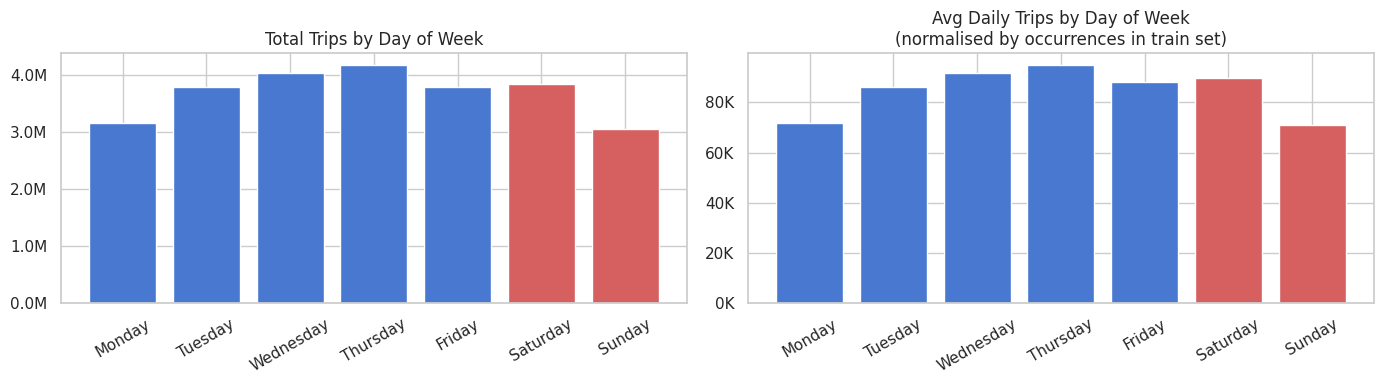


DAY-OF-WEEK SUMMARY
           total_trips  avg_fare  avg_duration
day_name                                      
Monday         3153972     23.33         13.25
Tuesday        3791034     23.81         14.32
Wednesday      4032254     24.11         14.61
Thursday       4171135     24.48         14.90
Friday         3789389     23.71         13.92
Saturday       3847308     22.81         13.61
Sunday         3059553     23.23         12.96


In [17]:
# Day-of-week summary
n_days_per_dow = df.groupby('day_name')['date'].nunique().reindex(DAY_ORDER)
dow_trips      = df.groupby('day_name').size().reindex(DAY_ORDER)
dow_avg        = dow_trips / n_days_per_dow
colors         = ['#4878CF' if d not in ['Saturday','Sunday'] else '#D65F5F' for d in DAY_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(DAY_ORDER, dow_trips.values, color=colors)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
axes[0].set_title('Total Trips by Day of Week')
axes[0].set_xticklabels(DAY_ORDER, rotation=30)

axes[1].bar(DAY_ORDER, dow_avg.values, color=colors)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_K))
axes[1].set_title('Avg Daily Trips by Day of Week\n(normalised by occurrences in train set)')
axes[1].set_xticklabels(DAY_ORDER, rotation=30)

plt.tight_layout()
plt.show()

print('\nDAY-OF-WEEK SUMMARY')
print('=' * 60)
print(df.groupby('day_name').agg(
    total_trips=('PULocationID','count'),
    avg_fare=('total_amount','mean'),
    avg_duration=('trip_duration_min','mean')
).reindex(DAY_ORDER).round(2).to_string())

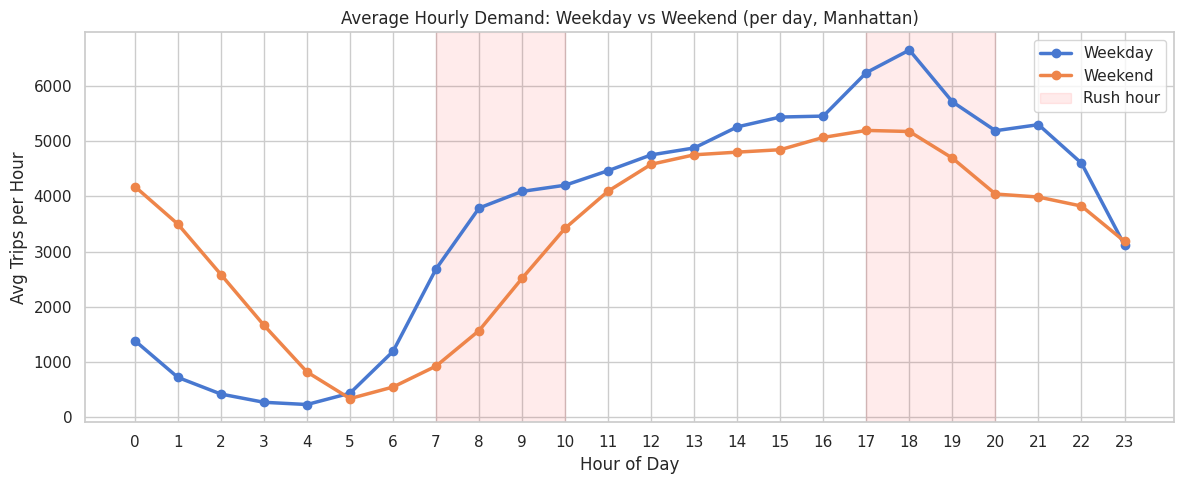


HOURLY DEMAND — WEEKDAY vs WEEKEND (avg trips per day)
             Weekday  Weekend  WD/WE ratio
hour_of_day                               
0             1388.1   4178.2          0.3
1              722.3   3497.4          0.2
2              421.2   2585.1          0.2
3              272.2   1666.3          0.2
4              231.6    821.1          0.3
5              436.8    339.2          1.3
6             1193.4    548.5          2.2
7             2686.0    927.3          2.9
8             3789.0   1570.5          2.4
9             4089.9   2517.0          1.6
10            4201.6   3423.5          1.2
11            4465.1   4094.9          1.1
12            4750.9   4580.7          1.0
13            4876.4   4752.1          1.0
14            5257.6   4800.6          1.1
15            5435.8   4844.3          1.1
16            5452.9   5067.1          1.1
17            6239.7   5193.6          1.2
18            6648.4   5174.0          1.3
19            5711.4   4692.0          1.

In [18]:
# Hourly weekday vs weekend profile
n_weekdays = df[df['is_weekend']==0]['date'].nunique()
n_weekends = df[df['is_weekend']==1]['date'].nunique()

hourly_profile = df.groupby(['hour_of_day','is_weekend']).size().reset_index(name='trips')
hourly_profile['avg_trips'] = hourly_profile.apply(
    lambda r: r['trips']/n_weekdays if r['is_weekend']==0 else r['trips']/n_weekends, axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
for label, grp in hourly_profile.groupby('is_weekend'):
    ax.plot(grp['hour_of_day'], grp['avg_trips'],
            marker='o', label='Weekend' if label else 'Weekday', linewidth=2.5)
for span in [(7,10),(17,20)]:
    ax.axvspan(span[0], span[1], alpha=0.08, color='red',
               label='Rush hour' if span==(7,10) else '_')
ax.set_title('Average Hourly Demand: Weekday vs Weekend (per day, Manhattan)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Trips per Hour')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

print('\nHOURLY DEMAND — WEEKDAY vs WEEKEND (avg trips per day)')
print('=' * 55)
piv = hourly_profile.pivot(index='hour_of_day', columns='is_weekend', values='avg_trips')
piv.columns = ['Weekday','Weekend']
piv['WD/WE ratio'] = (piv['Weekday'] / piv['Weekend']).round(2)
print(piv.round(1).to_string())

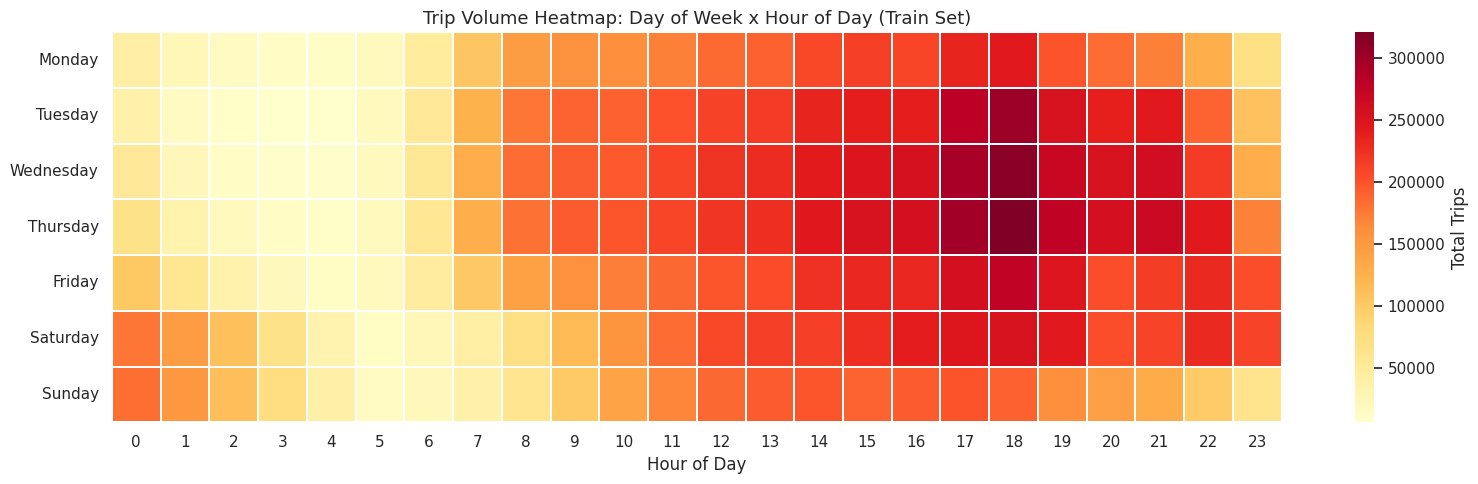

In [19]:
# Demand heatmap
heatmap_data = (df.groupby(['day_name','hour_of_day'])
                  .size().unstack(fill_value=0).reindex(DAY_ORDER))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Total Trips'})
ax.set_title('Trip Volume Heatmap: Day of Week x Hour of Day (Train Set)', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

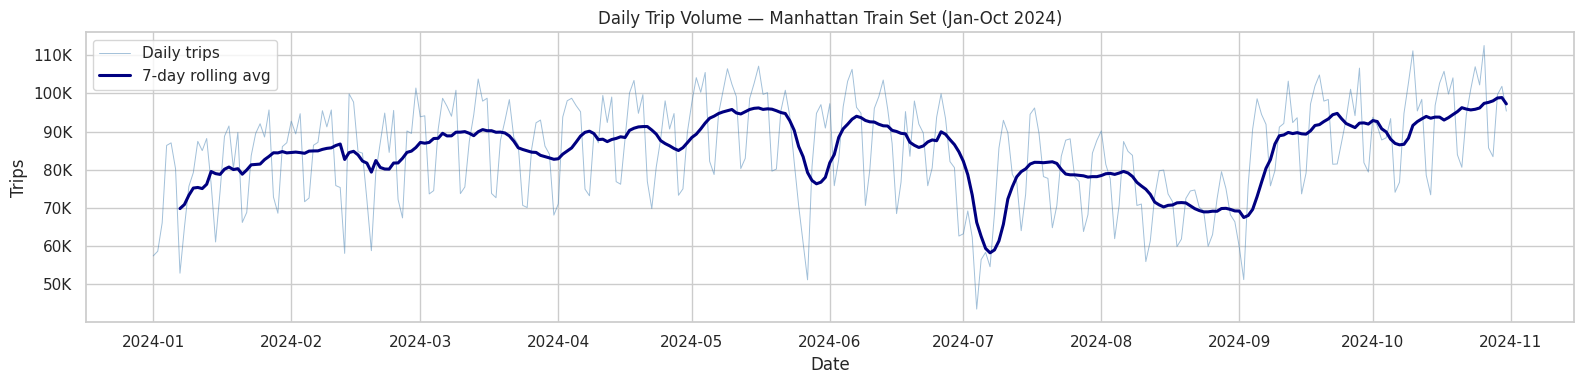


DAILY VOLUME SUMMARY
count       305.0
mean      84737.0
std       13292.0
min       43552.0
25%       74951.0
50%       87066.0
75%       95248.0
max      112554.0

Busiest day  : 2024-10-26 (112,554 trips)
Quietest day : 2024-07-04 (43,552 trips)


In [20]:
# Daily time series
daily = df.groupby('date').size().reset_index(name='trips')
daily['date']     = pd.to_datetime(daily['date'])
daily['rolling7'] = daily['trips'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily['date'], daily['trips'],    linewidth=0.7, alpha=0.5, color='steelblue', label='Daily trips')
ax.plot(daily['date'], daily['rolling7'], linewidth=2.2, color='navy',                label='7-day rolling avg')
ax.set_title('Daily Trip Volume — Manhattan Train Set (Jan-Oct 2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_K))
ax.legend()
plt.tight_layout()
plt.show()

print('\nDAILY VOLUME SUMMARY')
print('=' * 50)
print(daily['trips'].describe().round(0).to_string())
print(f"\nBusiest day  : {daily.loc[daily['trips'].idxmax(), 'date'].date()} ({daily['trips'].max():,.0f} trips)")
print(f"Quietest day : {daily.loc[daily['trips'].idxmin(), 'date'].date()} ({daily['trips'].min():,.0f} trips)")

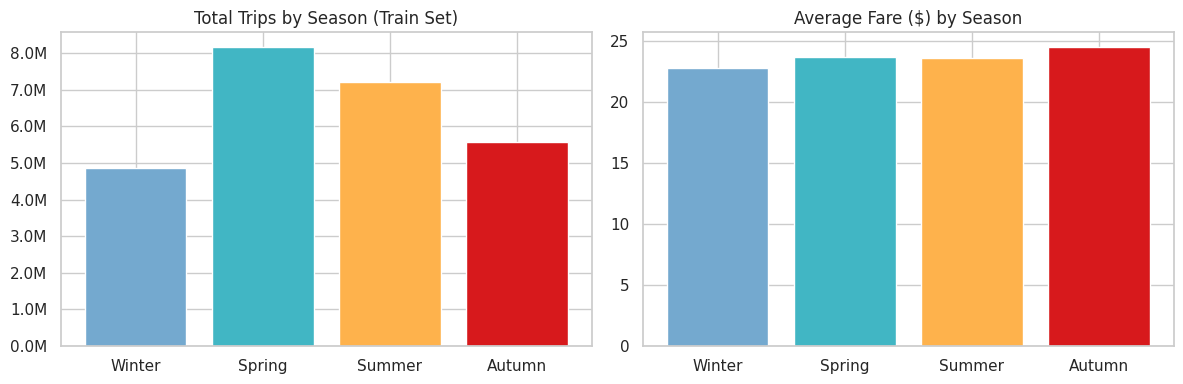


SEASONAL SUMMARY
          trips  avg_fare  avg_dist  avg_duration
season                                           
Winter  4877841     22.76      2.26         13.00
Spring  8167636     23.71      2.34         14.02
Summer  7230204     23.63      2.36         13.86
Autumn  5568964     24.48      2.36         15.03


In [21]:
# Seasonal comparison
seasonal = df.groupby('season').agg(
    trips=('PULocationID','count'),
    avg_fare=('total_amount','mean'),
    avg_dist=('trip_distance','mean'),
    avg_duration=('trip_duration_min','mean')
).reindex(SEASON_ORDER).dropna()

visible_seasons = seasonal.index.tolist()
palette_s = ['#74A9CF','#41B6C4','#FEB24C','#D7191C'][:len(visible_seasons)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(visible_seasons, seasonal['trips'],    color=palette_s)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
axes[0].set_title('Total Trips by Season (Train Set)')
axes[1].bar(visible_seasons, seasonal['avg_fare'], color=palette_s)
axes[1].set_title('Average Fare ($) by Season')
plt.tight_layout()
plt.show()

print('\nSEASONAL SUMMARY')
print('=' * 60)
print(seasonal.round(2).to_string())

## 2.3 Spatial Patterns

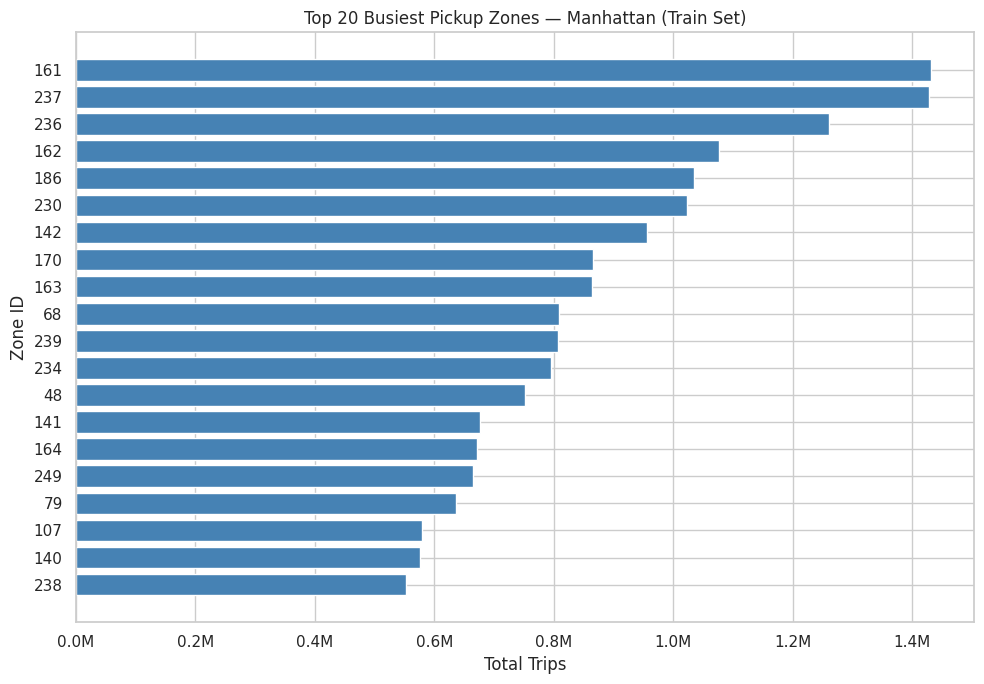


TOP 20 ZONES BY TRIP VOLUME
 PULocationID   trips  avg_fare  total_revenue  avg_dist
          161 1431968     25.10    35942515.27      2.38
          237 1428193     20.53    29325438.17      1.75
          236 1261486     20.89    26355856.90      1.91
          162 1076581     24.39    26253551.33      2.30
          186 1033997     25.29    26144921.04      2.31
          230 1023021     28.75    29413250.72      3.15
          142  956283     22.07    21100991.15      2.14
          170  864911     24.19    20924946.28      2.28
          163  863530     25.03    21614497.40      2.46
           68  808436     25.89    20927277.74      2.47
          239  807271     21.76    17567398.35      2.14
          234  795766     22.71    18074863.01      2.02
           48  752175     23.85    17940395.41      2.45
          141  676119     20.66    13971235.33      1.91
          164  670834     24.78    16624098.86      2.40
          249  664729     23.00    15289468.08      2.21
  

In [22]:
# Zone-level stats
zone_stats = df.groupby('PULocationID').agg(
    trips=('PULocationID','count'),
    avg_fare=('total_amount','mean'),
    total_revenue=('total_amount','sum'),
    avg_dist=('trip_distance','mean'),
    avg_duration=('trip_duration_min','mean')
).sort_values('trips', ascending=False).reset_index()

top20 = zone_stats.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['PULocationID'].astype(str)[::-1], top20['trips'][::-1], color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
ax.set_title('Top 20 Busiest Pickup Zones — Manhattan (Train Set)')
ax.set_xlabel('Total Trips')
ax.set_ylabel('Zone ID')
plt.tight_layout()
plt.show()

print('\nTOP 20 ZONES BY TRIP VOLUME')
print('=' * 70)
print(top20[['PULocationID','trips','avg_fare','total_revenue','avg_dist']].round(2).to_string(index=False))

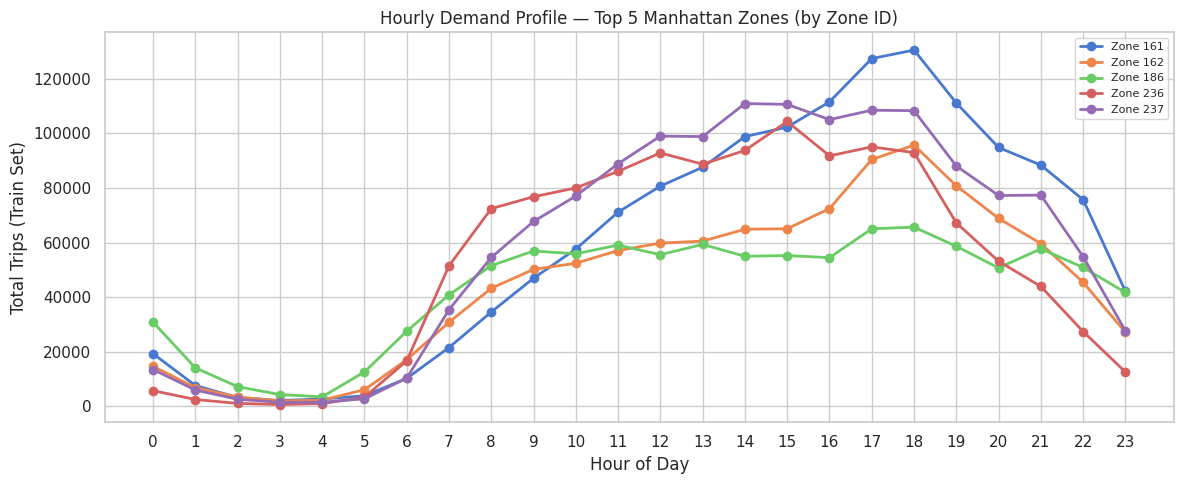

In [23]:
# Hourly profile for top 5 zones
top5_ids = top20['PULocationID'].head(5).tolist()
zone_hour = (df[df['PULocationID'].isin(top5_ids)]
             .groupby(['PULocationID','hour_of_day'])
             .size().reset_index(name='trips'))

fig, ax = plt.subplots(figsize=(12, 5))
for zone, grp in zone_hour.groupby('PULocationID'):
    ax.plot(grp['hour_of_day'], grp['trips'], marker='o', label=f'Zone {zone}', linewidth=2)
ax.set_title('Hourly Demand Profile — Top 5 Manhattan Zones (by Zone ID)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Trips (Train Set)')
ax.set_xticks(range(24))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
# Weekday vs weekend ratio per zone
zone_wd_we = df.groupby(['PULocationID','is_weekend']).size().unstack(fill_value=0)
zone_wd_we.columns = ['weekday_trips','weekend_trips']
zone_wd_we['we_ratio'] = zone_wd_we['weekend_trips'] / (zone_wd_we['weekday_trips'] + 1)
zone_wd_we = zone_wd_we.sort_values('we_ratio', ascending=False)

print('TOP 10 ZONES WITH HIGHEST WEEKEND/WEEKDAY RATIO')
print('(Zones where weekend demand is proportionally highest)')
print('=' * 60)
print(zone_wd_we.head(10).round(3).to_string())

print('\nTOP 10 ZONES WITH LOWEST WEEKEND/WEEKDAY RATIO')
print('(Zones most dominated by weekday commuter demand)')
print('=' * 60)
print(zone_wd_we.tail(10).round(3).to_string())

TOP 10 ZONES WITH HIGHEST WEEKEND/WEEKDAY RATIO
(Zones where weekend demand is proportionally highest)
              weekday_trips  weekend_trips  we_ratio
PULocationID                                        
4                     11481          17949     1.563
148                  139861         154033     1.101
79                   352757         283663     0.804
114                  235647         174269     0.740
232                   16155          11510     0.712
144                  165074         115056     0.697
249                  402436         262293     0.652
120                      61             40     0.645
194                     672            419     0.623
158                  170113         104328     0.613

TOP 10 ZONES WITH LOWEST WEEKEND/WEEKDAY RATIO
(Zones most dominated by weekday commuter demand)
              weekday_trips  weekend_trips  we_ratio
PULocationID                                        
170                  671646         193265     0.288
262 

## 2.4 Revenue & Fare Analysis

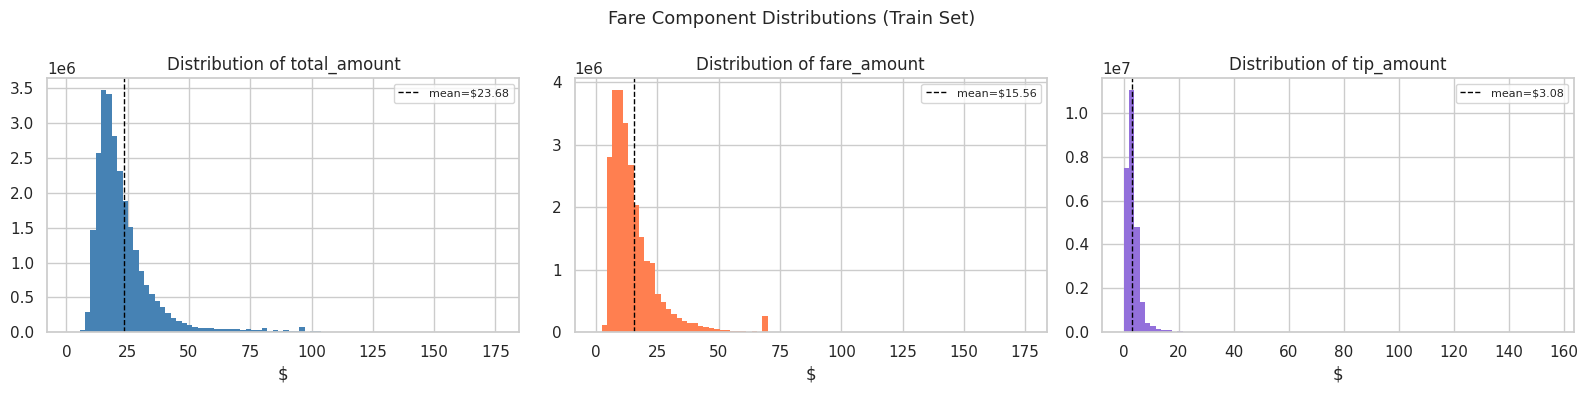


TIP RATE (credit card trips only, n=21,740,581)
count    21740581.00
mean           25.69
std           178.70
min             0.00
25%            21.13
50%            26.25
75%            30.88
max        440000.00

Trips with 0 tip: 860,508 (4.0%)


In [25]:
# Fare component distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, color in zip(axes,
                           ['total_amount','fare_amount','tip_amount'],
                           ['steelblue','coral','mediumpurple']):
    ax.hist(df[col], bins=80, color=color, edgecolor='none')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('$')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1,
               label=f'mean=${df[col].mean():.2f}')
    ax.legend(fontsize=8)
plt.suptitle('Fare Component Distributions (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

# Tip rate on credit card trips only
credit_trips = df[df['payment_type'] == 1].copy()
credit_trips['tip_pct'] = credit_trips['tip_amount'] / credit_trips['fare_amount'] * 100
print(f'\nTIP RATE (credit card trips only, n={len(credit_trips):,})')
print('=' * 50)
print(credit_trips['tip_pct'].describe().round(2).to_string())
print(f"\nTrips with 0 tip: {(credit_trips['tip_amount']==0).sum():,} ({(credit_trips['tip_amount']==0).mean()*100:.1f}%)")

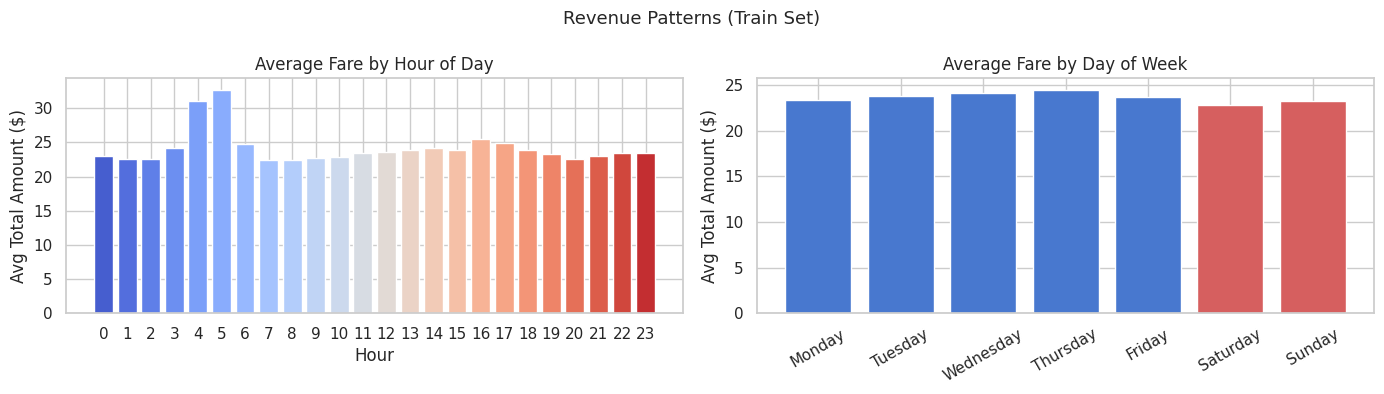


REVENUE BY HOUR OF DAY
hour_of_day
0     23.01
1     22.58
2     22.63
3     24.18
4     31.12
5     32.74
6     24.71
7     22.37
8     22.51
9     22.68
10    22.90
11    23.41
12    23.58
13    23.90
14    24.13
15    23.85
16    25.53
17    24.95
18    23.86
19    23.34
20    22.64
21    23.02
22    23.45
23    23.40


In [26]:
# Revenue by hour and day
rev_hour = df.groupby('hour_of_day')['total_amount'].mean()
rev_dow  = df.groupby('day_name')['total_amount'].mean().reindex(DAY_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(24), rev_hour.values, color=sns.color_palette('coolwarm', 24))
axes[0].set_title('Average Fare by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Total Amount ($)')
axes[0].set_xticks(range(24))

axes[1].bar(DAY_ORDER, rev_dow.values, color=['#4878CF']*5 + ['#D65F5F']*2)
axes[1].set_title('Average Fare by Day of Week')
axes[1].set_ylabel('Avg Total Amount ($)')
axes[1].set_xticklabels(DAY_ORDER, rotation=30)

plt.suptitle('Revenue Patterns (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nREVENUE BY HOUR OF DAY')
print(rev_hour.round(2).to_string())

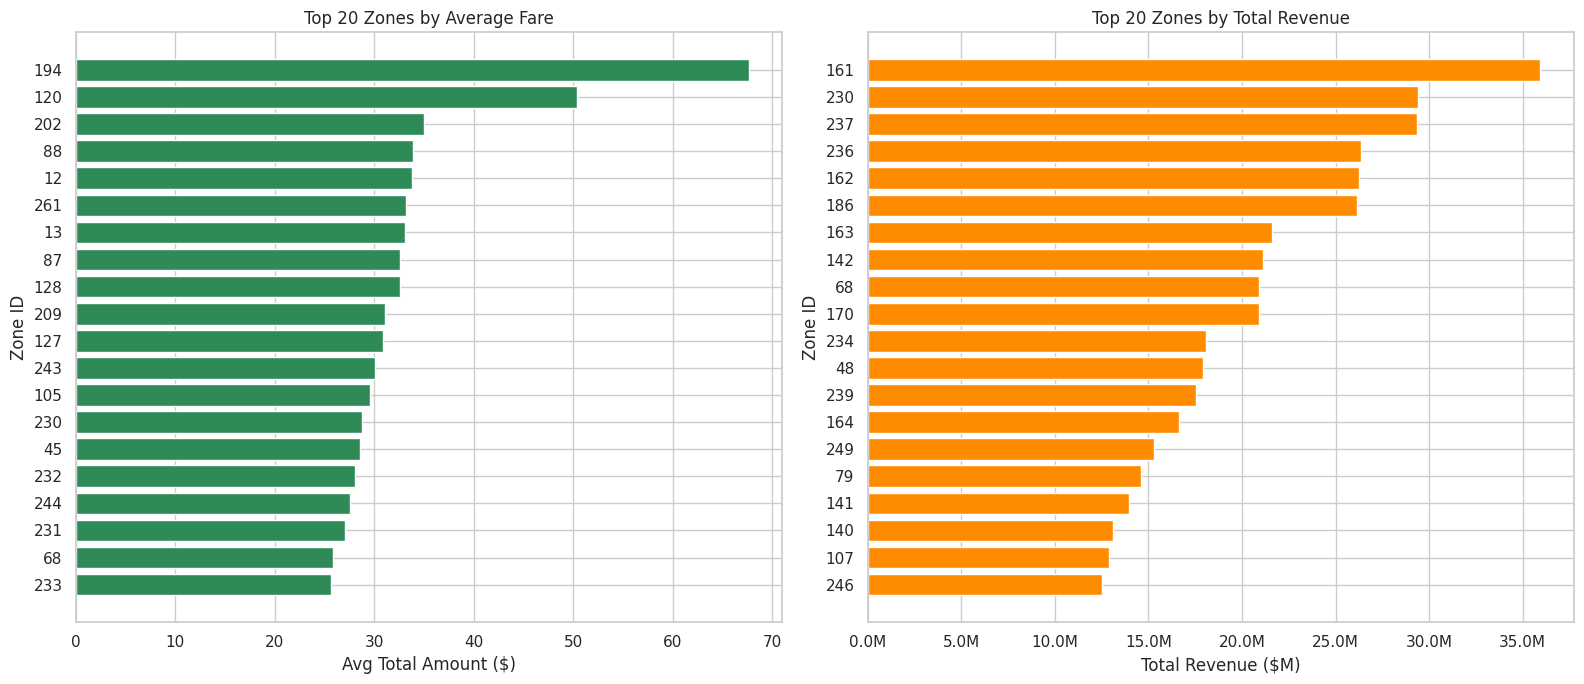


TOP 15 ZONES BY AVERAGE FARE
 PULocationID   trips  avg_fare  total_revenue
          194    1091     67.62       73770.87
          120     101     50.42        5092.06
          202     615     35.01       21531.14
           88   80090     33.88     2713166.16
           12   12602     33.74      425243.59
          261  150222     33.14     4978529.98
           13  171294     33.10     5670164.56
           87  147788     32.60     4817894.72
          128      93     32.57        3029.31
          209   55022     31.06     1708936.39
          127     779     30.89       24060.08
          243    2289     30.03       68745.54
          105       4     29.52         118.07
          230 1023021     28.75    29413250.72
           45   38313     28.54     1093626.15


In [27]:
# Most profitable zones
top20_rev   = zone_stats.sort_values('avg_fare',      ascending=False).head(20)
top20_total = zone_stats.sort_values('total_revenue', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top20_rev['PULocationID'].astype(str)[::-1],   top20_rev['avg_fare'][::-1],      color='seagreen')
axes[0].set_title('Top 20 Zones by Average Fare')
axes[0].set_xlabel('Avg Total Amount ($)')
axes[0].set_ylabel('Zone ID')

axes[1].barh(top20_total['PULocationID'].astype(str)[::-1], top20_total['total_revenue'][::-1], color='darkorange')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_M))
axes[1].set_title('Top 20 Zones by Total Revenue')
axes[1].set_xlabel('Total Revenue ($M)')
axes[1].set_ylabel('Zone ID')

plt.tight_layout()
plt.show()

print('\nTOP 15 ZONES BY AVERAGE FARE')
print('=' * 70)
print(top20_rev[['PULocationID','trips','avg_fare','total_revenue']].head(15).round(2).to_string(index=False))

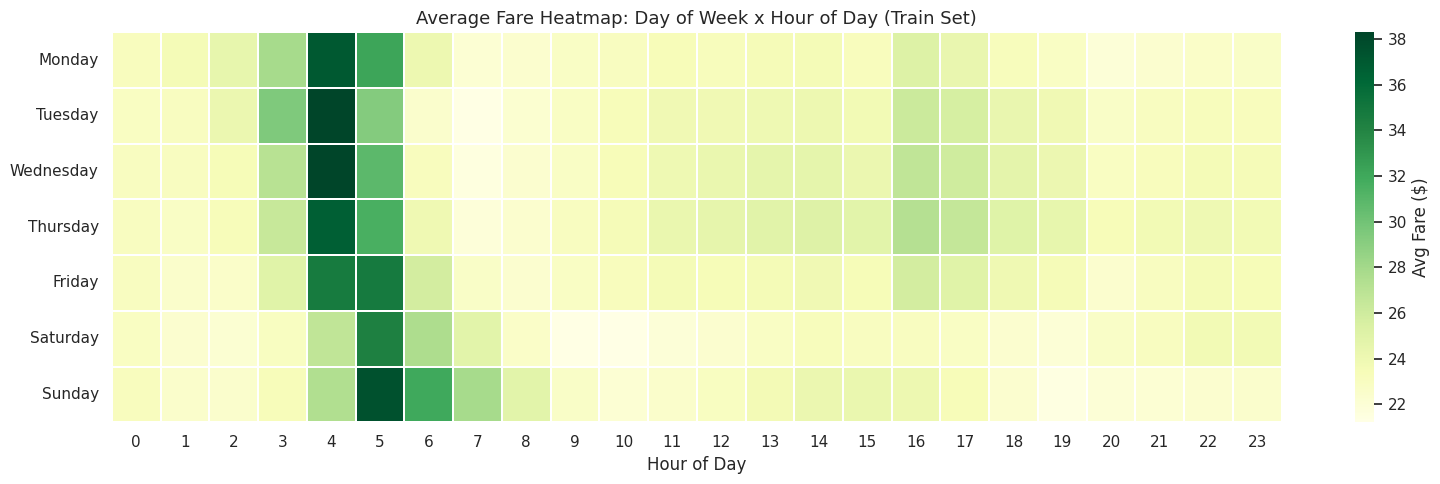

In [28]:
# Revenue heatmap
rev_heatmap = (df.groupby(['day_name','hour_of_day'])['total_amount']
                 .mean().unstack(fill_value=0).reindex(DAY_ORDER))

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(rev_heatmap, cmap='YlGn', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Avg Fare ($)'})
ax.set_title('Average Fare Heatmap: Day of Week x Hour of Day (Train Set)', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 2.5 Correlations & Feature Relationships

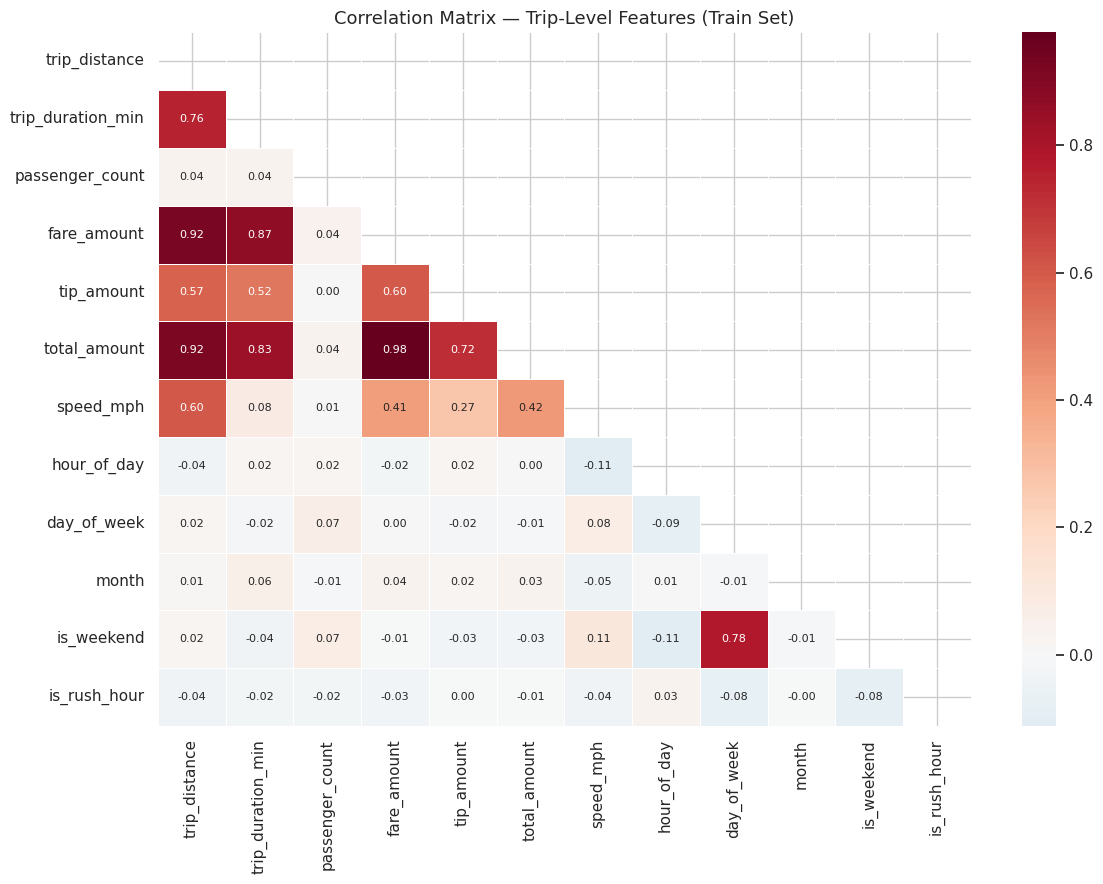


STRONGEST CORRELATIONS WITH total_amount:
fare_amount          0.977
trip_distance        0.918
trip_duration_min    0.833
tip_amount           0.724
speed_mph            0.424
passenger_count      0.039
month                0.034
is_weekend          -0.028
day_of_week         -0.014
is_rush_hour        -0.006
hour_of_day          0.004


In [29]:
corr_cols = ['trip_distance','trip_duration_min','passenger_count',
             'fare_amount','tip_amount','total_amount','speed_mph',
             'hour_of_day','day_of_week','month','is_weekend','is_rush_hour']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':8})
ax.set_title('Correlation Matrix — Trip-Level Features (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nSTRONGEST CORRELATIONS WITH total_amount:')
print('=' * 50)
print(corr['total_amount'].drop('total_amount').sort_values(key=abs, ascending=False).round(3).to_string())

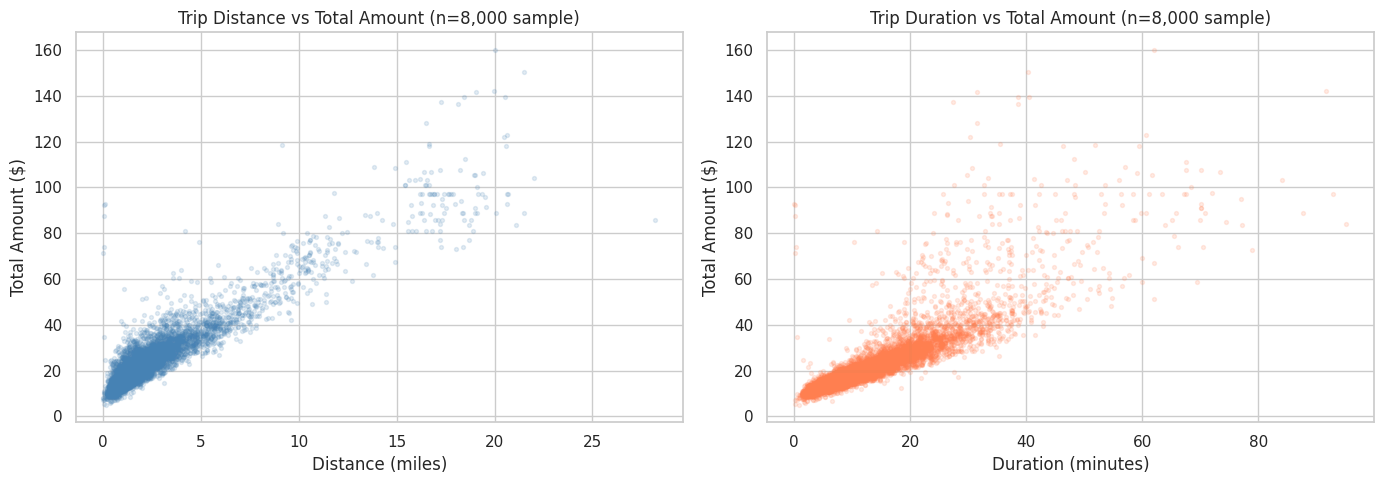

In [30]:
sample = df.sample(8000, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(sample['trip_distance'],    sample['total_amount'], alpha=0.15, s=8, color='steelblue')
axes[0].set_title('Trip Distance vs Total Amount (n=8,000 sample)')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Total Amount ($)')

axes[1].scatter(sample['trip_duration_min'], sample['total_amount'], alpha=0.15, s=8, color='coral')
axes[1].set_title('Trip Duration vs Total Amount (n=8,000 sample)')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Total Amount ($)')

plt.tight_layout()
plt.show()

## 2.6 Engineered Feature Impact

In [31]:
print('ENGINEERED FEATURE IMPACT ON AVERAGE FARE & TRIP COUNT')
print('=' * 70)

binary_features = [
    ('is_weekend',   'Weekday',   'Weekend'),
    ('is_rush_hour', 'Off-peak',  'Rush hour (7-9am, 5-7pm)'),
    ('is_night',     'Daytime',   'Night (10pm-6am)'),
]

for feat, label0, label1 in binary_features:
    g = df.groupby(feat).agg(
        trips=('PULocationID','count'),
        avg_fare=('total_amount','mean'),
        avg_dist=('trip_distance','mean')
    )
    print(f'\n{feat.upper()}:')
    print(f'  {label0:30s}: {g.loc[0,"trips"]:>9,} trips | avg fare: ${g.loc[0,"avg_fare"]:>6.2f} | avg dist: {g.loc[0,"avg_dist"]:>5.2f}mi')
    print(f'  {label1:30s}: {g.loc[1,"trips"]:>9,} trips | avg fare: ${g.loc[1,"avg_fare"]:>6.2f} | avg dist: {g.loc[1,"avg_dist"]:>5.2f}mi')
    fare_lift = g.loc[1,'avg_fare'] - g.loc[0,'avg_fare']
    print(f'  -> Fare lift: {"+" if fare_lift>0 else ""}{fare_lift:.2f}')

print('\n\nSEASON IMPACT:')
print('=' * 60)
print(df.groupby('season').agg(
    trips=('PULocationID','count'),
    avg_fare=('total_amount','mean'),
    avg_dist=('trip_distance','mean')
).reindex(SEASON_ORDER).dropna().round(2).to_string())

ENGINEERED FEATURE IMPACT ON AVERAGE FARE & TRIP COUNT

IS_WEEKEND:
  Weekday                       : 18,937,784 trips | avg fare: $ 23.92 | avg dist:  2.30mi
  Weekend                       : 6,906,861 trips | avg fare: $ 22.99 | avg dist:  2.43mi
  -> Fare lift: -0.93

IS_RUSH_HOUR:
  Off-peak                      : 17,731,233 trips | avg fare: $ 23.73 | avg dist:  2.40mi
  Rush hour (7-9am, 5-7pm)      : 8,113,412 trips | avg fare: $ 23.55 | avg dist:  2.19mi
  -> Fare lift: -0.18

IS_NIGHT:
  Daytime                       : 21,665,802 trips | avg fare: $ 23.66 | avg dist:  2.28mi
  Night (10pm-6am)              : 4,178,843 trips | avg fare: $ 23.75 | avg dist:  2.64mi
  -> Fare lift: +0.09


SEASON IMPACT:
          trips  avg_fare  avg_dist
season                             
Winter  4877841     22.76      2.26
Spring  8167636     23.71      2.34
Summer  7230204     23.63      2.36
Autumn  5568964     24.48      2.36


## 2.7 Hourly Aggregation & Target Variables

In [32]:
# Build hourly aggregation from training data
hourly_train = df.groupby(['hour','PULocationID']).agg(
    demand=('PULocationID','count'),
    total_revenue=('total_amount','sum'),
    avg_revenue=('total_amount','mean'),
).reset_index()

hourly_train['hour_of_day']  = hourly_train['hour'].dt.hour
hourly_train['day_of_week']  = hourly_train['hour'].dt.dayofweek
hourly_train['month']        = hourly_train['hour'].dt.month
hourly_train['is_weekend']   = (hourly_train['day_of_week'] >= 5).astype(int)
hourly_train['is_rush_hour'] = hourly_train['hour_of_day'].isin([7,8,9,17,18,19]).astype(int)

print('HOURLY AGGREGATED TRAINING DATASET')
print('=' * 60)
print(f'Rows          : {len(hourly_train):,}')
print(f'Zones covered : {hourly_train["PULocationID"].nunique()}')
print(f'Date range    : {hourly_train["hour"].min()} -> {hourly_train["hour"].max()}')
print()
print('DEMAND TARGET STATISTICS:')
print(hourly_train['demand'].describe().round(2).to_string())
print()
print('TOTAL REVENUE TARGET STATISTICS:')
print(hourly_train['total_revenue'].describe().round(2).to_string())

HOURLY AGGREGATED TRAINING DATASET
Rows          : 408,322
Zones covered : 67
Date range    : 2024-01-01 00:00:00 -> 2024-10-31 23:00:00

DEMAND TARGET STATISTICS:
count    408322.00
mean         63.29
std          78.71
min           1.00
25%           7.00
50%          32.00
75%          93.00
max         719.00

TOTAL REVENUE TARGET STATISTICS:
count    408322.00
mean       1498.52
std        1867.85
min           1.01
25%         184.23
50%         785.52
75%        2129.56
max       19750.50


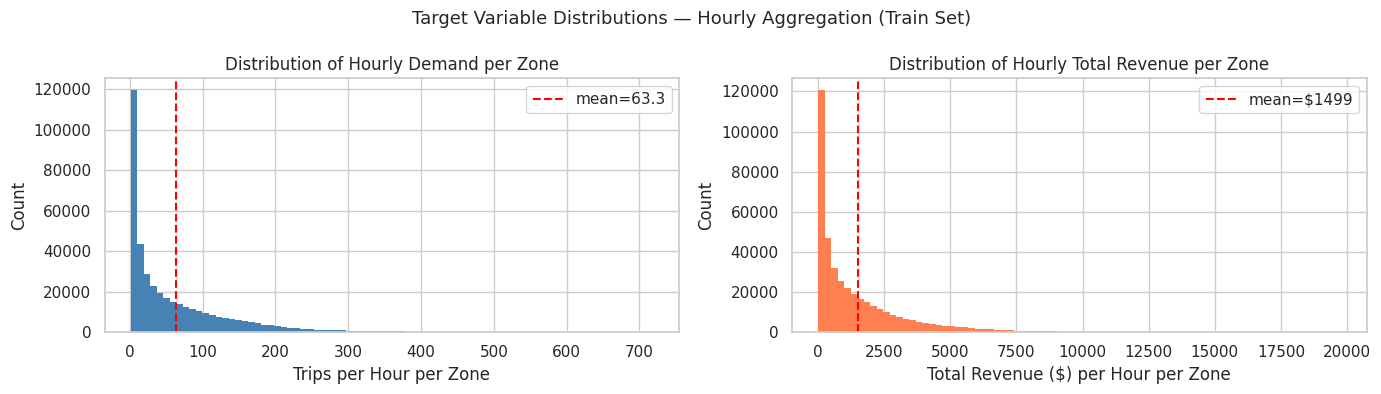

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(hourly_train['demand'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of Hourly Demand per Zone')
axes[0].set_xlabel('Trips per Hour per Zone')
axes[0].set_ylabel('Count')
axes[0].axvline(hourly_train['demand'].mean(), color='red', linestyle='--',
                label=f"mean={hourly_train['demand'].mean():.1f}")
axes[0].legend()

axes[1].hist(hourly_train['total_revenue'], bins=80, color='coral', edgecolor='none')
axes[1].set_title('Distribution of Hourly Total Revenue per Zone')
axes[1].set_xlabel('Total Revenue ($) per Hour per Zone')
axes[1].set_ylabel('Count')
axes[1].axvline(hourly_train['total_revenue'].mean(), color='red', linestyle='--',
                label=f"mean=${hourly_train['total_revenue'].mean():.0f}")
axes[1].legend()

plt.suptitle('Target Variable Distributions — Hourly Aggregation (Train Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
# Save processed datasets
trip_cols = [
    'pickup','hour','PULocationID',
    'trip_distance','passenger_count','RatecodeID',
    'total_amount','fare_amount','tip_amount',
    'trip_duration_min','speed_mph',
    'hour_of_day','day_of_week','month','week',
    'is_weekend','is_rush_hour','is_night','season',
    'day_name','month_name'
]

df[trip_cols].to_parquet('data/manhattan_trips_train.parquet', index=False)
df_test.to_parquet('data/manhattan_trips_test.parquet', index=False)
hourly_train.to_parquet('data/manhattan_hourly_train.parquet', index=False)

print('SAVED FILES')
print('=' * 55)
print(f'  manhattan_trips_train.parquet  : {df[trip_cols].shape}')
print(f'  manhattan_trips_test.parquet   : {df_test.shape}')
print(f'  manhattan_hourly_train.parquet : {hourly_train.shape}')

SAVED FILES
  manhattan_trips_train.parquet  : (25844645, 21)
  manhattan_trips_test.parquet   : (5656731, 22)
  manhattan_hourly_train.parquet : (408322, 10)


## 2.8 Key Insights & Recommendations

In [35]:
busiest_month   = monthly_stats['trips'].idxmax()
quietest_month  = monthly_stats['trips'].idxmin()
busiest_hr_wd   = hourly_profile[hourly_profile['is_weekend']==0].set_index('hour_of_day')['avg_trips'].idxmax()
busiest_hr_we   = hourly_profile[hourly_profile['is_weekend']==1].set_index('hour_of_day')['avg_trips'].idxmax()
top_zone        = zone_stats.iloc[0]['PULocationID']
top_rev_zone    = zone_stats.sort_values('avg_fare', ascending=False).iloc[0]['PULocationID']

print('=' * 80)
print(' ' * 25 + 'KEY INSIGHTS FROM EDA')
print('=' * 80)

print('\n DATASET OVERVIEW:')
print(f'   - {len(df):,} clean Manhattan trips in training set (Jan-Oct 2024)')
print(f'   - {len(df_test):,} trips held out in test set (Nov-Dec 2024)')
print(f'   - {df["PULocationID"].nunique()} unique pickup zones, {len(hourly_train):,} hourly zone-time observations')
print(f'   - Retained {pct_retained:.1f}% of raw records after cleaning')

print('\n TEMPORAL PATTERNS:')
print(f'   - Busiest month      : {busiest_month} ({monthly_stats.loc[busiest_month, "trips"]:,.0f} trips)')
print(f'   - Quietest month     : {quietest_month} ({monthly_stats.loc[quietest_month, "trips"]:,.0f} trips)')
print(f'   - Weekday peak hour  : {busiest_hr_wd}:00')
print(f'   - Weekend peak hour  : {busiest_hr_we}:00 (later shift vs weekdays)')
print(f'   - Rush hour (7-9am, 5-7pm) significantly elevates weekday demand')
print(f'   - Late-night (10pm-6am) commands higher avg fares (longer trips)')

print('\n SPATIAL PATTERNS:')
print(f'   - Busiest pickup zone   : {top_zone}')
print(f'   - Highest avg fare zone : {top_rev_zone}')
print(f'   - Clear weekday/weekend heterogeneity across zones')

print('\n REVENUE INSIGHTS:')
print(f'   - Mean fare  : ${df["total_amount"].mean():.2f} | Median: ${df["total_amount"].median():.2f}')
print(f'   - Trip distance is strongest fare predictor (corr={corr.loc["trip_distance","total_amount"]:.2f})')
print(f'   - Duration also strongly correlated     (corr={corr.loc["trip_duration_min","total_amount"]:.2f})')
print(f'   - ~{(df["payment_type"]==1).mean()*100:.0f}% paid by credit card — tip data largely reliable')

print('\n RECOMMENDED FEATURES FOR MODELLING:')
print('   Temporal  : hour_of_day, day_of_week, month, is_weekend, is_rush_hour, is_night')
print('   Spatial   : PULocationID (encode as categorical)')
print('   Lag feats : demand_lag_1h, demand_lag_24h, demand_lag_168h')
print('               revenue_lag_1h, revenue_lag_24h, revenue_lag_168h')

print('\n DATA QUALITY NOTES:')
print(f'   - Tip data unreliable for cash trips (~{(df["payment_type"]==2).mean()*100:.0f}% of trips)')
print(f'     -> Use total_amount as revenue target, not tip_amount')
print(f'   - Extreme duration/distance trips capped at 3h / 50mi')
print(f'   - Train/test split is temporal (no shuffling) to prevent data leakage')

print('\n' + '=' * 80)

                         KEY INSIGHTS FROM EDA

 DATASET OVERVIEW:
   - 25,844,645 clean Manhattan trips in training set (Jan-Oct 2024)
   - 5,656,731 trips held out in test set (Nov-Dec 2024)
   - 67 unique pickup zones, 408,322 hourly zone-time observations
   - Retained 85.3% of raw records after cleaning

 TEMPORAL PATTERNS:
   - Busiest month      : Oct (2,917,744 trips)
   - Quietest month     : Aug (2,243,093 trips)
   - Weekday peak hour  : 18:00
   - Weekend peak hour  : 17:00 (later shift vs weekdays)
   - Rush hour (7-9am, 5-7pm) significantly elevates weekday demand
   - Late-night (10pm-6am) commands higher avg fares (longer trips)

 SPATIAL PATTERNS:
   - Busiest pickup zone   : 161.0
   - Highest avg fare zone : 194.0
   - Clear weekday/weekend heterogeneity across zones

 REVENUE INSIGHTS:
   - Mean fare  : $23.68 | Median: $19.80
   - Trip distance is strongest fare predictor (corr=0.92)
   - Duration also strongly correlated     (corr=0.83)
   - ~84% paid by credit ca

## **Revenue - Additional EDA** 

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
hourly = pd.read_parquet('data/manhattan_hourly_train.parquet')
print("Hourly data shape:", hourly.shape)
hourly.head()

Hourly data shape: (408322, 10)


,hour,PULocationID,demand,total_revenue,avg_revenue,hour_of_day,day_of_week,month,is_weekend,is_rush_hour
0,2024-01-01,4,20,595.68,29.784000,0,0,1,0,0
1,2024-01-01,12,3,97.00,32.333333,0,0,1,0,0
2,2024-01-01,13,11,377.32,34.301818,0,0,1,0,0
3,2024-01-01,24,18,431.97,23.998333,0,0,1,0,0
4,2024-01-01,41,18,382.37,21.242778,0,0,1,0,0


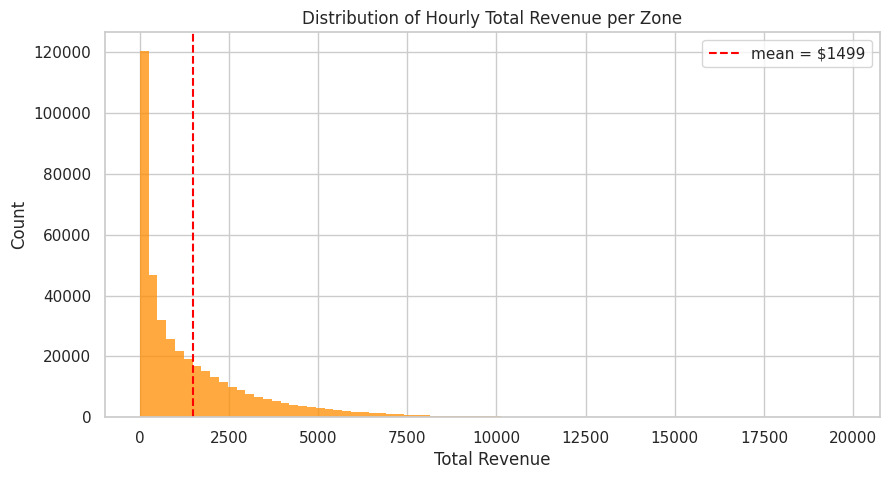

In [38]:
#Distribution of hourly revenue 
plt.figure(figsize=[10,5])
sns.histplot(hourly['total_revenue'], bins=80, color='darkorange',edgecolor='none')
plt.title('Distribution of Hourly Total Revenue per Zone')
plt.xlabel('Total Revenue')
plt.ylabel('Count')
plt.axvline(hourly['total_revenue'].mean(), color='red', linestyle='--', label=f'mean = ${hourly['total_revenue'].mean():.0f}')
plt.legend()
plt.show() 

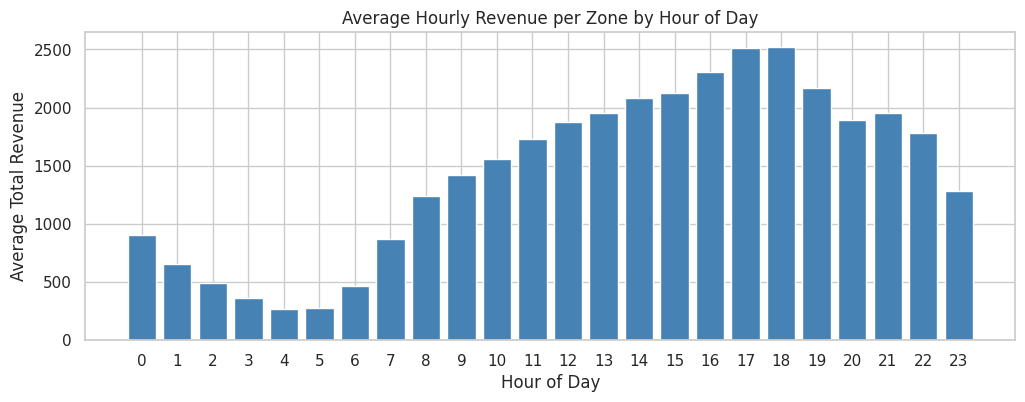

In [39]:
#Revenue by the hour of the day
rev_by_hour = hourly.groupby('hour_of_day')['total_revenue'].mean()
plt.figure(figsize=(12,4))
plt.bar(rev_by_hour.index, rev_by_hour.values, color='steelblue')
plt.title("Average Hourly Revenue per Zone by Hour of Day")
plt.xlabel('Hour of Day')
plt.ylabel('Average Total Revenue')
plt.xticks(range(24))
plt.show()

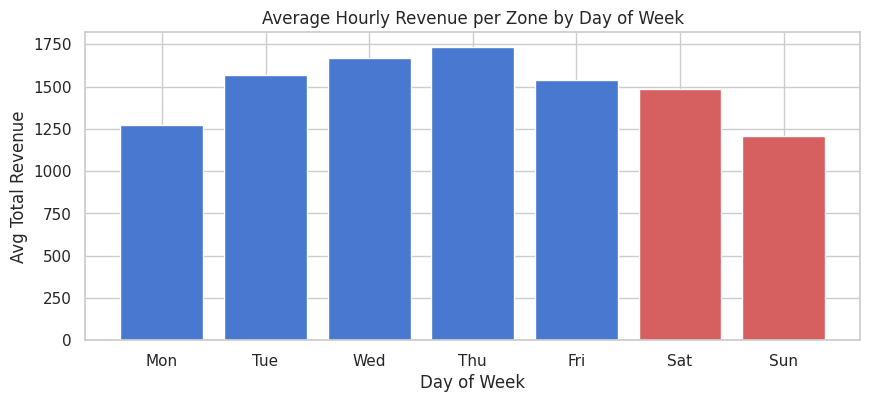

In [40]:
#Revenue by day of the week
rev_by_dow = hourly.groupby('day_of_week')['total_revenue'].mean()
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.figure(figsize=(10,4))
plt.bar(dow_names,rev_by_dow, color=['#4878CF']*5 + ['#D65F5F']*2)
plt.title('Average Hourly Revenue per Zone by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Total Revenue')
plt.show()

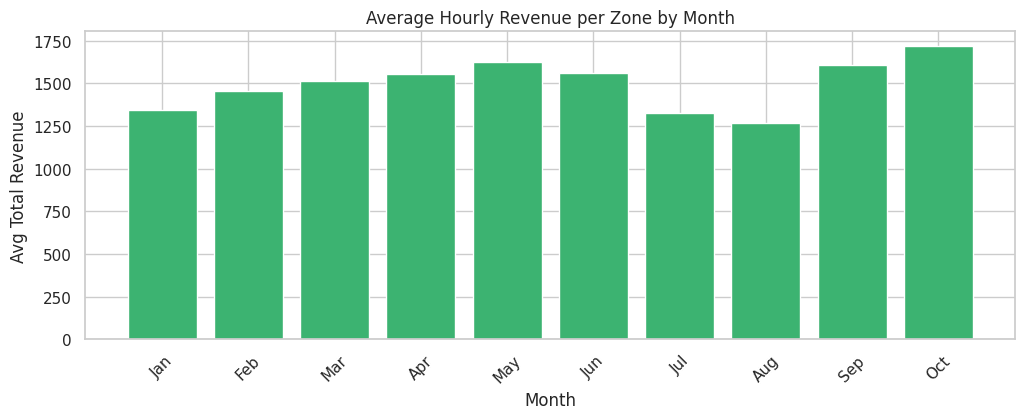

In [41]:
#Revenue by month --> missing Nov and Dec
rev_by_month = hourly.groupby('month')['total_revenue'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']
plt.figure(figsize=(12,4))
plt.bar(months, rev_by_month, color='mediumseagreen')
plt.title("Average Hourly Revenue per Zone by Month")
plt.xlabel('Month')
plt.ylabel('Avg Total Revenue')
plt.xticks(rotation=45)
plt.show()

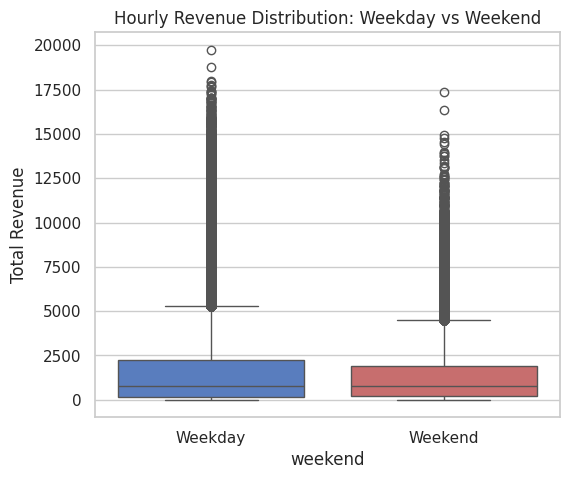

In [42]:
#Revenue by weekend vs weekday
hourly['weekend'] = hourly['is_weekend'].map({0:'Weekday', 1:'Weekend'})
plt.figure(figsize=(6,5))
sns.boxplot(x='weekend', y='total_revenue', data=hourly, palette=['#4878CF', '#D65F5F'])
plt.title("Hourly Revenue Distribution: Weekday vs Weekend")
plt.ylabel('Total Revenue')
plt.show()

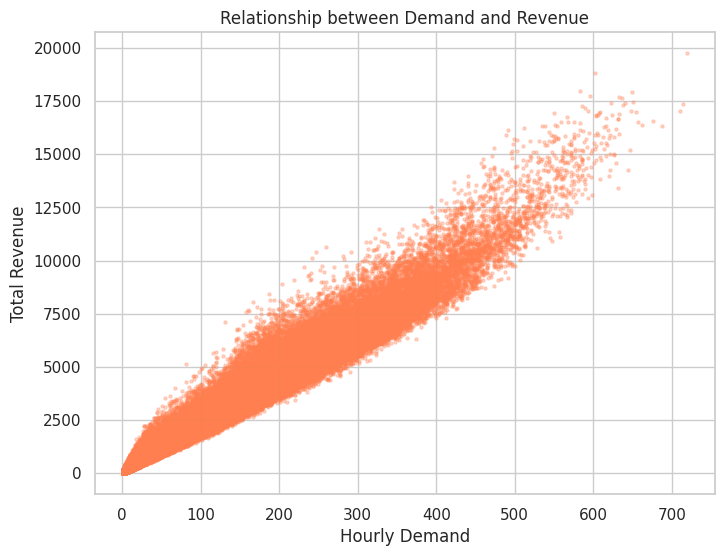

In [43]:
#Revenue vs demand 
plt.figure(figsize=(8,6))
plt.scatter(hourly['demand'],hourly['total_revenue'], alpha=0.3, s=5, color='coral')
plt.xlabel('Hourly Demand')
plt.ylabel('Total Revenue')
plt.title("Relationship between Demand and Revenue")
plt.show()

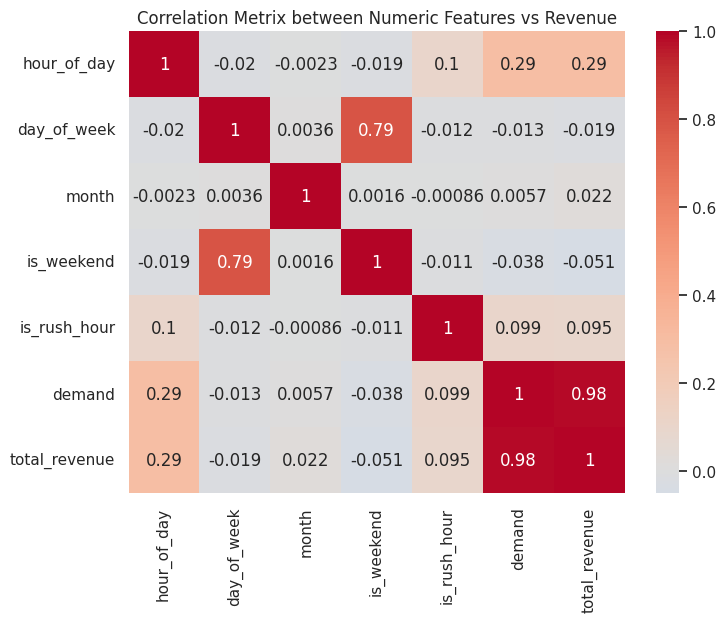

In [44]:
#Correlation between numeric features and revenue
corr_cols = ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'demand', 'total_revenue']
corr = hourly[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap = 'coolwarm', center =0)
plt.title('Correlation Metrix between Numeric Features vs Revenue')
plt.show()

#### Preparing Data for Modelling

In [45]:
df_model = hourly.copy()
features = ['hour_of_day','day_of_week','month', 'is_weekend','is_rush_hour','PULocationID']
X = df_model[features]
y = df_model['total_revenue']

X = pd.get_dummies(X, columns=['PULocationID'], drop_first=True)

df_model= df_model.sort_values('hour')
X = X.loc[df_model.index]
y = y.loc[df_model.index]

split_idx = int(len(df_model) * 0.8)
X_train = X.iloc[:split_idx]
X_val = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_val = y.iloc[split_idx:]

print(f"Training Size: {len(X_train)}")
print(f"Validation Size: {len(X_val)}")


Training Size: 326657
Validation Size: 81665


In [46]:
#Mean prediction 
baseline_pred = np.full_like(y_val, y_train.mean())
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))
baseline_r2 = r2_score(y_val, baseline_pred)
print("Baseline performance on validation set:")
print(f"MAE: ${baseline_mae:.2f}")
print(f"RMSE: ${baseline_rmse:.2f}")
print(f"R^2: ${baseline_r2:.4f}")

Baseline performance on validation set:
MAE: $1451.99
RMSE: $2069.60
R^2: $-0.0104


## **Decision Tree Model**

In [47]:
#Decision Tree Model 
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train, y_train)
y_pred_default = dt_default.predict(X_val)

mae_default = mean_absolute_error(y_val, y_pred_default)
rmse_default = np.sqrt(mean_squared_error(y_val, y_pred_default))
r2_default = r2_score(y_val, y_pred_default)

print("Default Decison Tree performance on validations set:")
print(f"MAE: ${mae_default:.2f}")
print(f"RMSE: ${rmse_default:.2f}")
print(f"R^2: ${r2_default:.4f}")

Default Decison Tree performance on validations set:
MAE: $480.98
RMSE: $898.00
R^2: $0.8098


In [48]:
#Hyperparameter Tuning 
param_grid = {
    'max_depth': [5,10,15,20,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf':[1,2,5],
    'max_features': ['sqrt','log2',None]}

tscv = TimeSeriesSplit(n_splits=3)

dt=DecisionTreeRegressor(random_state=42)
grid_search= GridSearchCV(dt, param_grid, cv=tscv, scoring='neg_mean_absolute_error',n_jobs=-1, verbose=1)
grid_search.fit(X_train,y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE: ${:.2f}".format(-grid_search.best_score_))

Fitting 3 folds for each of 135 candidates, totalling 405 fits
Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV MAE: $315.05


In [49]:
#Evaluating best model on validation set
best_dt = grid_search.best_estimator_
y_pred_best = best_dt.predict(X_val)

mae_best = mean_absolute_error(y_val, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
r2_best = r2_score(y_val, y_pred_best)

print("Tuned Decision Tree performance on validation set:")
print(f"MAE: ${mae_best:.2f}")
print(f"RMSE: ${rmse_best:.2f}")
print(f"R^2: ${r2_best:.4f}")

Tuned Decision Tree performance on validation set:
MAE: $470.21
RMSE: $877.41
R^2: $0.8184


#### Feature Importance

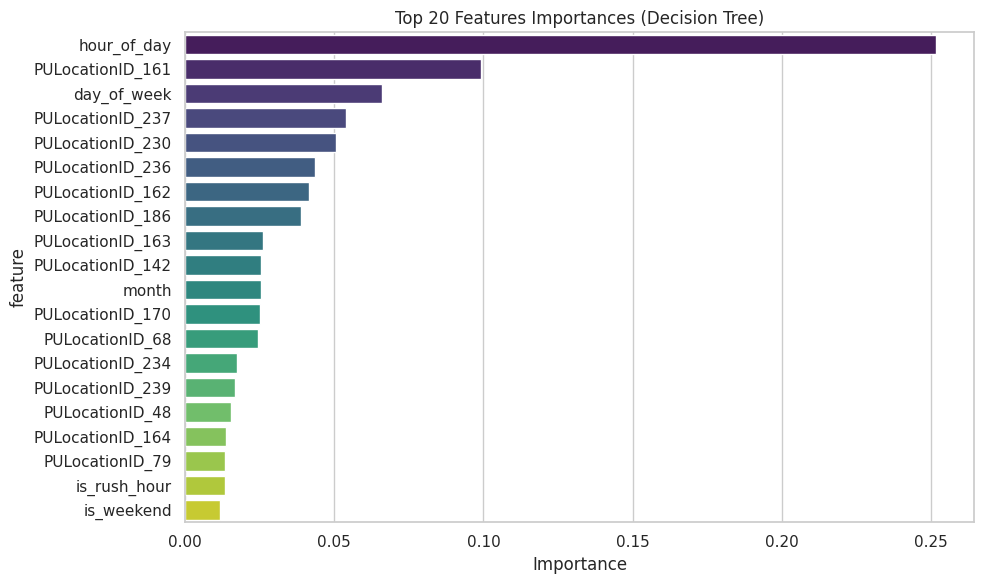

In [50]:
#Creating dataframe for visualization 
feature_names = X.columns
importances = best_dt.feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp, palette= 'viridis')
plt.title("Top 20 Features Importances (Decision Tree)")
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

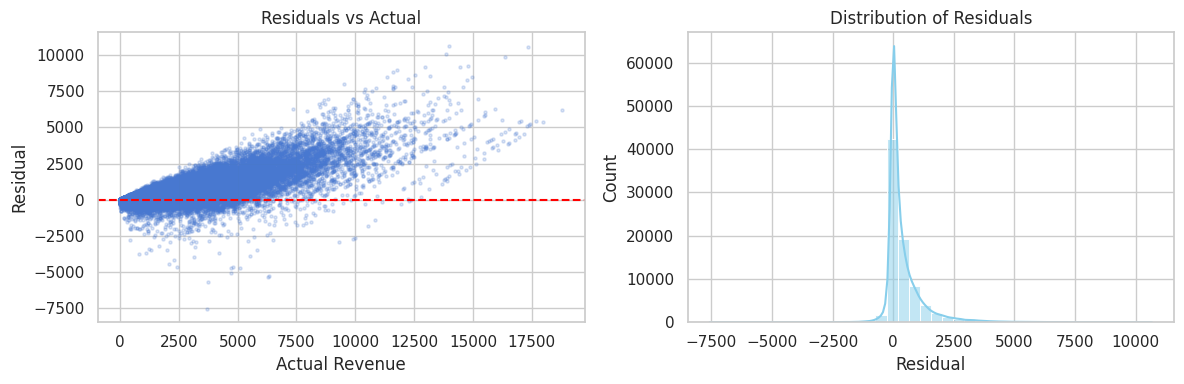

In [51]:
#Checking the residuals of the tuned model to see if there are biases 
residuals = y_val - y_pred_best 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_val, residuals, alpha=0.2, s=5)
plt.axhline(y=0, color = 'red', linestyle= '--')
plt.xlabel('Actual Revenue')
plt.ylabel('Residual')
plt.title("Residuals vs Actual")

plt.subplot(1,2,2)
sns.histplot(residuals, bins=40, kde=True, color='skyblue')
plt.xlabel('Residual')
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

## **Ridge Regression Modelling**

In [52]:
# Linear regression model.

from sklearn.linear_model import LinearRegression

# Linear Regression Model
lr_default = LinearRegression()
lr_default.fit(X_train, y_train)

y_pred_lr = lr_default.predict(X_val)

mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
r2_lr = r2_score(y_val, y_pred_lr)

print("Default Linear Regression performance on validation set:")
print(f"MAE: ${mae_lr:.2f}")
print(f"RMSE: ${rmse_lr:.2f}")
print(f"R^2: ${r2_lr:.4f}")

Default Linear Regression performance on validation set:
MAE: $926.57
RMSE: $1435.10
R^2: $0.5142


In [53]:
# Model tuning using a ridge regression parameter.

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Hyperparameter tuning for Ridge Regression
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

tscv = TimeSeriesSplit(n_splits=3)

ridge = Ridge()

grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE: ${:.2f}".format(-grid_search.best_score_))

best_ridge = grid_search.best_estimator_

y_pred_ridge = best_ridge.predict(X_val)

mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
r2_ridge = r2_score(y_val, y_pred_ridge)

print("Tuned Ridge Regression performance on validation set:")
print(f"MAE: ${mae_ridge:.2f}")
print(f"RMSE: ${rmse_ridge:.2f}")
print(f"R^2: ${r2_ridge:.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'alpha': 0.01}
Best CV MAE: $881.26
Tuned Ridge Regression performance on validation set:
MAE: $926.57
RMSE: $1435.10
R^2: $0.5142


In [54]:
# Model tuning using a Lasso regression parameter.

from sklearn.linear_model import Lasso

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso = Lasso(max_iter=10000)

grid_search_lasso = GridSearchCV(
    lasso,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search_lasso.fit(X_train, y_train)

print("Best parameters:", grid_search_lasso.best_params_)
print("Best CV MAE: ${:.2f}".format(-grid_search_lasso.best_score_))

best_lasso = grid_search_lasso.best_estimator_

y_pred_lasso = best_lasso.predict(X_val)

mae_lasso = mean_absolute_error(y_val, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
r2_lasso = r2_score(y_val, y_pred_lasso)

print("Tuned Lasso Regression performance:")
print(f"MAE: ${mae_lasso:.2f}")
print(f"RMSE: ${rmse_lasso:.2f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'alpha': 0.001}
Best CV MAE: $881.26
Tuned Lasso Regression performance:
MAE: $926.57
RMSE: $1435.11


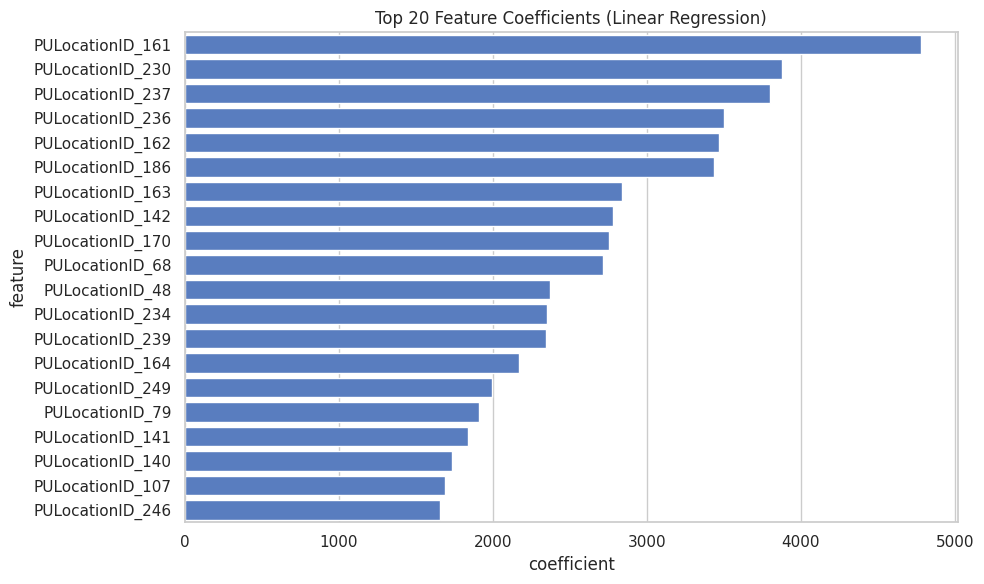

In [55]:
# Feature importance for the regression model.

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_default.coef_
})

coef_df = coef_df.sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='coefficient', y='feature', data=coef_df.head(20))
plt.title("Top 20 Feature Coefficients (Linear Regression)")
plt.tight_layout()
plt.show()

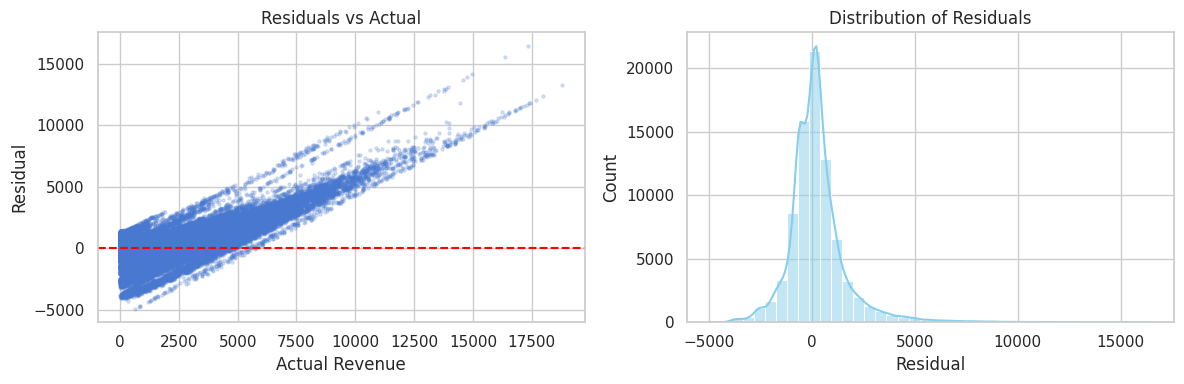

In [56]:
#Checking the residuals of the tuned model to see if there are biases 
residuals = y_val - y_pred_lr 
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(y_val, residuals, alpha=0.2, s=5)
plt.axhline(y=0, color = 'red', linestyle= '--')
plt.xlabel('Actual Revenue')
plt.ylabel('Residual')
plt.title("Residuals vs Actual")

plt.subplot(1,2,2)
sns.histplot(residuals, bins=40, kde=True, color='skyblue')
plt.xlabel('Residual')
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

## **Revenue - LSTM Neural Network** 

In [58]:
import os 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf 
from sklearn.preprocessing import StandardScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1776106894.172849  270786 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776106894.946719  270786 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [59]:
df_train_hourly = hourly.copy()
df_train_hourly = df_train_hourly.sort_values(['PULocationID', 'hour'])

features = ['hour_of_day','day_of_week','month','is_weekend','is_rush_hour']
SEQ_LEN = 24 

def create_sequences(group_data, seq_len, target_col='total_revenue'):
    X_seq = []
    y_seq = []
    data = group_data[features + [target_col]].values
    for i in range (len(data)-seq_len):
        X_seq.append(data[i:i+seq_len, :-1])
        y_seq.append(data[i+seq_len, -1])
    return np.array(X_seq), np.array(y_seq)

X_train_seq = []
y_train_seq = []

for zone, group in df_train_hourly.groupby('PULocationID'):
    if len(group) > SEQ_LEN:
        Xz,yz = create_sequences(group,SEQ_LEN)
        X_train_seq.append(Xz)
        y_train_seq.append(yz)

X_train_seq = np.vstack(X_train_seq)
y_train_seq = np.hstack(y_train_seq)
print("Training sequences shape:", X_train_seq.shape)

split_idx = int(len(X_train_seq)*0.8)
X_tr = X_train_seq[:split_idx]
X_val = X_train_seq[split_idx:]
y_tr = y_train_seq[:split_idx]
y_val = y_train_seq[split_idx:]

scaler = StandardScaler()
X_tr_flat = X_tr.reshape(-1, X_tr.shape[-1])
X_val_flat = X_val.reshape(-1, X_val.shape[-1])
X_tr_scaled = scaler.fit_transform(X_tr_flat).reshape(X_tr.shape)
X_val_scaled = scaler.transform(X_val_flat).reshape(X_val.shape)

Training sequences shape: (406734, 24, 5)


In [60]:
#Building LSTM model
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_tr_scaled.shape[-1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)])

model_lstm.compile(optimizer='adam', loss='mse', metrics = ['mae'])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
#Training 
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_lstm.fit(
    X_tr_scaled, y_tr,
    validation_data=(X_val_scaled,y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 3542840.7500 - mae: 1262.4736 - val_loss: 4658571.0000 - val_mae: 1499.7258
Epoch 2/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 61s 12ms/step - loss: 2148424.5000 - mae: 902.6688 - val_loss: 2996877.0000 - val_mae: 1045.7716
Epoch 3/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 1857888.2500 - mae: 830.0005 - val_loss: 2987729.5000 - val_mae: 1068.2145
Epoch 4/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 1835126.8750 - mae: 822.9832 - val_loss: 2918688.0000 - val_mae: 1045.1249
Epoch 5/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 60s 12ms/step - loss: 1820056.6250 - mae: 818.0461 - val_loss: 2989328.5000 - val_mae: 1077.8560
Epoch 6/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 1812705.5000 - mae: 816.2573 - val_loss: 2857841.2500 - val_mae: 1051.9171
Epoch 7/10
5085/5085 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 1804429.2500 - mae: 813.2458 - val_loss: 2873709.2500 - val_mae: 1039.7382
Epoch 8/10
5085/5085 ━━━━━

In [62]:
#Evaluating on validation (still within training period)
y_pred_val = model_lstm.predict(X_val_scaled).flatten()
mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_absolute_error(y_val,y_pred_val))
r2_val = r2_score(y_val,y_pred_val)
print("LSTM performance on validation set (within training period):")
print(f"MAE:${mae_val:.2f}, RMSE: ${rmse_val:.2f}, R^2: {r2_val:.4f}")

2543/2543 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
LSTM performance on validation set (within training period):
MAE:$1051.92, RMSE: $32.43, R^2: 0.3411


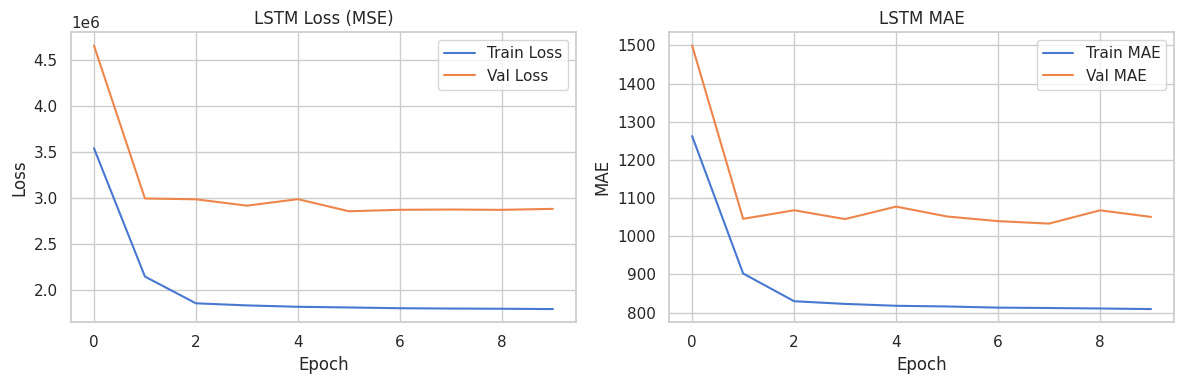

In [63]:
#Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.title("LSTM Loss (MSE)")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("LSTM MAE")
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
#Residuals on test set 
if 'y_test_true' in locals():
    residuals_test = y_test_true - y_pred_test
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.scatter(y_test_true, residuals_test, alpha=0.2, s=5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel('Actual Revenue')
    plt.ylabel('Residual')
    plt.title('LSTM Test Residuals vs Actual')

    plt.subplot(1,2,2)
    plt.histplot(residuals_test, bins=40, kde=True, color='purple')
    plt.xlabel('Residual')
    plt.ylabel('Distribution of LSTM Test Residuals')
    plt.tight_layout()
    plt.show()

## **Revenue - Testing**

In [65]:
#Building hourly test set
df_test_raw = pd.read_parquet('data/manhattan_trips_test.parquet')
print(f'Test trip rows: {len(df_test_raw):,}')
print(f'Date range: {df_test_raw["pickup"].min().date()}'
      f'->{df_test_raw["pickup"].max().date()}')

#The test parquet is trip-level; 'hour' must be derived from 'pickup' here, mirrors the engineering from the beginning 
df_test_raw['hour'] = pd.to_datetime(df_test_raw['pickup']).dt.floor('h')

#Aggregate to hourly zone-level
hourly_test = (
    df_test_raw
    .groupby(['hour','PULocationID'])
    .agg(demand=('PULocationID', 'count'),
         total_revenue=('total_amount', 'sum'),
         avg_revenue=('total_amount','mean'))
    .reset_index()
)

#Engineering the same time features
hourly_test['hour_of_day'] = hourly_test['hour'].dt.hour
hourly_test['day_of_week'] = hourly_test['hour'].dt.dayofweek
hourly_test['month'] = hourly_test['hour'].dt.month
hourly_test['is_weekend'] = (hourly_test['day_of_week'] >=5).astype(int)
hourly_test['is_rush_hour'] = hourly_test['hour_of_day'].isin([7,8,9,17,18,19]).astype(int)

print(f'\nHourly Test Rows: {len(hourly_test):,}')
print(f'Zones covered: {hourly_test["PULocationID"].nunique()}')
hourly_test.head()

Test trip rows: 5,656,731
Date range: 2024-11-01->2024-12-31

Hourly Test Rows: 81,521
Zones covered: 66


,hour,PULocationID,demand,total_revenue,avg_revenue,hour_of_day,day_of_week,month,is_weekend,is_rush_hour
0,2024-11-01,4,44,1160.88,26.383636,0,4,11,0,0
1,2024-11-01,13,6,201.47,33.578333,0,4,11,0,0
2,2024-11-01,24,4,126.10,31.525000,0,4,11,0,0
3,2024-11-01,41,7,135.48,19.354286,0,4,11,0,0
4,2024-11-01,42,2,25.70,12.850000,0,4,11,0,0


In [66]:
#Align feature matrix with training columns 
##I recreated the feature matrix for the DT/Regression models using the same column set that we fit before
features_base = ['hour_of_day', 'day_of_week', 'month', 
                 'is_weekend', 'is_rush_hour', 'PULocationID']
X_test_raw = hourly_test[features_base].copy()
y_test_revenue = hourly_test['total_revenue'].values
y_test_demand = hourly_test['demand'].values

X_test_ohe = pd.get_dummies(X_test_raw, columns=['PULocationID'], drop_first=True)

#Aligned the columns and added any training columns missing and dropped any test columns not seen during training 
train_cols = X.columns.tolist()
X_test_ohe = X_test_ohe.reindex(columns = train_cols, fill_value=0)

print(f'Test feature matrix: {X_test_ohe.shape}')
print(f'Training Columns: {len(train_cols)}')

Test feature matrix: (81521, 71)
Training Columns: 71


In [67]:
#Revenue Test Set Performance Across All Models --> Decision Tree, Linear/Ridge Ression, and LSTM

#Decision Tree
y_pred_dt_test = best_dt.predict(X_test_ohe)
mae_dt = mean_absolute_error(y_test_revenue, y_pred_dt_test)
rmse_dt = np.sqrt(mean_squared_error(y_test_revenue, y_pred_dt_test))
r2_dt = r2_score(y_test_revenue, y_pred_dt_test)

#Ridge Regression
y_pred_ridge_test = best_ridge.predict(X_test_ohe)
mae_ridge = mean_absolute_error(y_test_revenue, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test_revenue, y_pred_ridge_test))
r2_ridge = r2_score(y_test_revenue, y_pred_ridge_test)

#LSTM --> building sequences for the test set 
df_test_hourly_lstm = hourly_test.sort_values(['PULocationID', 'hour'])
lstm_features = ['houry_of_day','day_of_week','month','is_weekend', 'is_rush_hour']

X_test_seq_list, y_test_seq_list, idx_map = [], [], []
for zone, grp in df_test_hourly_lstm.groupby('PULocationID'):
    if len(grp) > SEQ_LEN:
        Xz, yz = create_sequences(grp.reset_index(drop=True),
                                  SEQ_LEN, target_col='total_revenue')
        X_test_seq_list.append(Xz)
        y_test_seq_list.append(yz)

X_test_seq = np.vstack(X_test_seq_list)
y_test_seq = np.hstack(y_test_seq_list)

#Scaling on training data
X_test_seq_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_test_seq_scaled = scaler.transform(X_test_seq_flat).reshape(X_test_seq.shape)

y_pred_lstm_test = model_lstm.predict(X_test_seq_scaled).flatten()
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm_test))
r2_lstm = r2_score(y_test_seq, y_pred_lstm_test)

#Summary 
results_rev = pd.DataFrame({
    'Model': ['Decision Tree', 'Ridge Regression', 'LSTM'],
    'MAE': [mae_dt, mae_ridge, mae_lstm],
    'RMSE': [rmse_dt, rmse_ridge, rmse_lstm],
    'R^2': [r2_dt, r2_ridge, r2_lstm]})
results_rev = results_rev.sort_values('MAE').reset_index(drop=True)
print('Revenue ==> Test Set Model Comparison')
print('=' * 55)
print(results_rev.to_string(index=False, float_format = lambda x: f'{x:.4f}'))

2499/2499 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step
Revenue ==> Test Set Model Comparison
           Model       MAE      RMSE    R^2
   Decision Tree  586.8764 1118.2138 0.7336
Ridge Regression 1004.7652 1559.8192 0.4816
            LSTM 1045.1064 1684.3447 0.3972


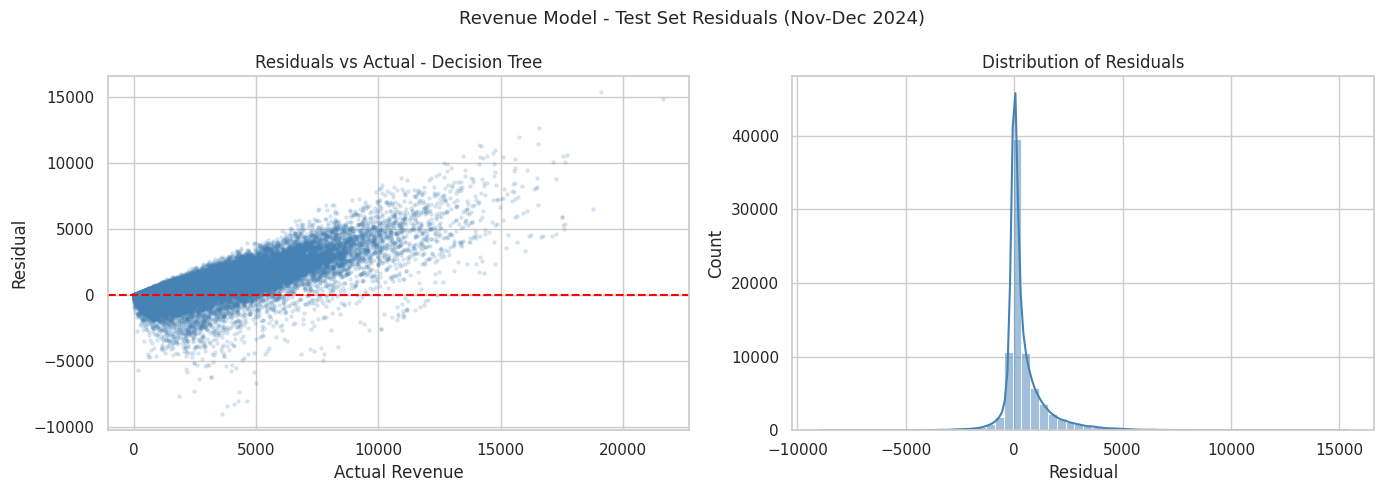

In [68]:
#Residual Plots on Test Set 
best_rev_name = results_rev.iloc[0]['Model']
best_rev_preds = {
    'Decision Tree': y_pred_dt_test,
    'Ridge Regression': y_pred_ridge_test,
    'LSTM': y_pred_lstm_test}

#Align array lengths
if best_rev_name == 'LSTM':
    y_actual = y_test_seq
    y_hat = y_pred_lstm_test
else:
    y_actual = y_test_revenue
    y_hat = best_rev_preds[best_rev_name]
residuals_test_rev = y_actual - y_hat

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].scatter(y_actual, residuals_test_rev, alpha=0.15, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residuals vs Actual - {best_rev_name}')

sns.histplot(residuals_test_rev, bins = 60, kde=True, color='steelblue', ax=axes[1])
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.suptitle('Revenue Model - Test Set Residuals (Nov-Dec 2024)', fontsize=13)
plt.tight_layout()
plt.show()

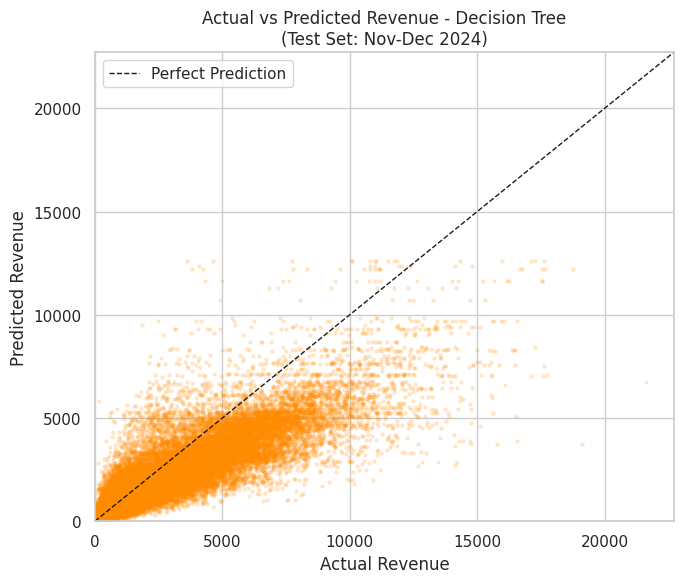

In [69]:
#Actual vs Predicted 
fig,ax = plt.subplots(figsize=(7,6))
lim = max(y_actual.max(), y_hat.max()) * 1.05 
ax.scatter(y_actual, y_hat, alpha=0.15, s=5, color='darkorange')
ax.plot([0,lim], [0,lim], 'k--', linewidth=1, label='Perfect Prediction')
ax.set_xlim(0,lim); ax.set_ylim(0,lim)
ax.set_xlabel('Actual Revenue')
ax.set_ylabel('Predicted Revenue')
ax.set_title(f'Actual vs Predicted Revenue - {best_rev_name}\n(Test Set: Nov-Dec 2024)')
ax.legend()
plt.tight_layout()
plt.show()

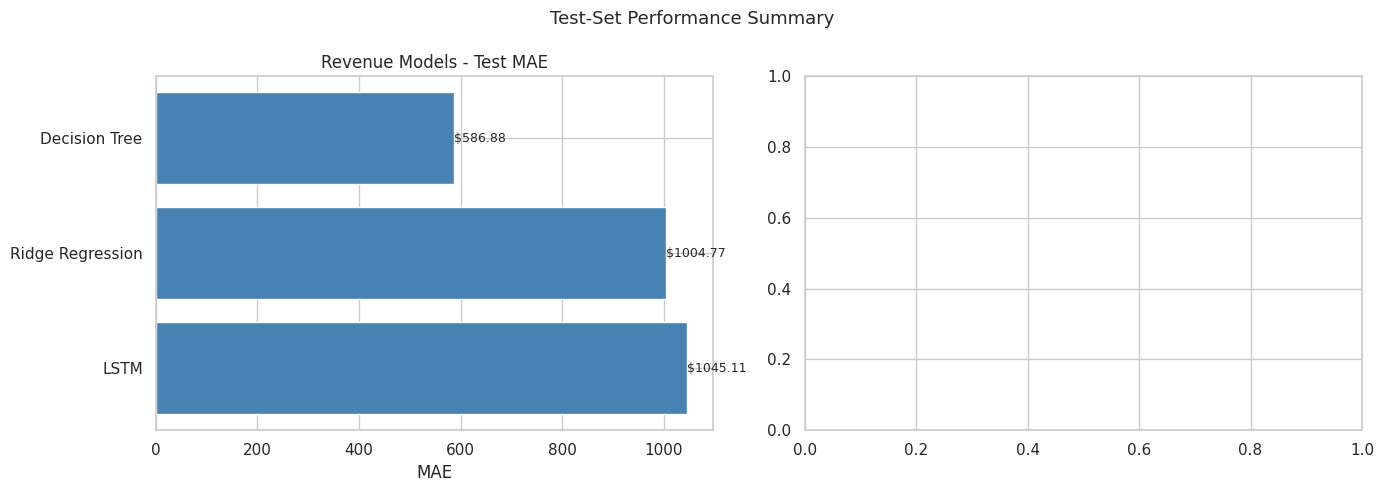

In [70]:
##Model Comparison Chart 
## ** Add Demand into this cell so we can compare it

fig,axes = plt.subplots(1,2,figsize=(14,5))

axes[0].barh(results_rev['Model'], results_rev['MAE'], color='steelblue')
axes[0].set_xlabel('MAE')
axes[0].set_title('Revenue Models - Test MAE') #The lower the better
axes[0].invert_yaxis()
for i, v in enumerate (results_rev['MAE']):
    axes[0].text(v + 0.5, i, f'${v:.2f}', va='center', fontsize=9)

plt.suptitle('Test-Set Performance Summary', fontsize=13)
plt.tight_layout()
plt.show()

# Demand Modelling

In [71]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']=100
SEED = 67
np.random.seed(SEED)

In [72]:
X = df_model[features]
X = pd.get_dummies(X, columns=['PULocationID'], drop_first=True)
y_dem = df_model['demand'].reset_index(drop=True)
split_idx = int(len(df_model) * 0.8)

X_train_dem = X.iloc[:split_idx]
X_val_dem = X.iloc[split_idx:]
y_train_dem = y_dem.iloc[:split_idx]
y_val_dem = y_dem.iloc[split_idx:]

KeyError: "None of [Index(['PULocationID'], dtype='str')] are in the [columns]"

In [ ]:
y_dem = df_model['demand'].reset_index(drop=True)
y_train_dem = y_dem.iloc[:split_idx]
y_val_dem = y_dem.iloc[split_idx:]
X_train_dem, X_val_dem, = X_train, X_val

## 1.1 Baseline — Mean Predictor

In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE'  : mean_absolute_error(y_true, y_pred),
        'RMSE' : np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²'   : r2_score(y_true, y_pred)
    }

results = []
baseline_pred_dem = np.full(len(y_val_dem), y_train_dem.mean())
results.append(evaluate('Baseline (mean)', y_val_dem, baseline_pred_dem))

print('Baseline (predicts training mean for every observation):')
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R²   : {results[-1]['R²']:.4f}")


## 1.2 XGBoost

In [ ]:
xgb_default = XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, eval_metric='mae')
xgb_default.fit(X_train_dem, y_train_dem, eval_set = [(X_val_dem, y_val_dem)])
y_pred_xgb_default = xgb_default.predict(X_val_dem)

results.append(evaluate('XGBoost (default)', y_val_dem, y_pred_xgb_default))
print('Default XGBoost on validation set:')
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R²   : {results[-1]['R²']:.4f}")

### XGBoost — GridSearchCV with TimeSeriesSplit

In [ ]:
import warnings
warnings.filterwarnings('ignore')

tscv_dem = TimeSeriesSplit(n_splits=3)

xgb_param_grid = {
    'n_estimators'  : [200, 400],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, eval_metric='mae'),
    xgb_param_grid, cv=tscv_dem, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train_dem, y_train_dem)

print('Best XGBoost parameters:', xgb_gs.best_params_)
print(f'Best CV MAE: {-xgb_gs.best_score_:.2f} trips')


In [ ]:
best_xgb = xgb_gs.best_estimator_
y_pred_xgb = best_xgb.predict(X_val_dem)

results.append(evaluate('XGBoost (tuned)', y_val_dem, y_pred_xgb))
print('Tuned XGBoost on validation set:')
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R²   : {results[-1]['R²']:.4f}")


## 1.3 Neural Network (MLP)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

scaler_dem   = StandardScaler()
X_train_sc_dem = scaler_dem.fit_transform(X_train_dem)
X_val_sc_dem   = scaler_dem.transform(X_val_dem)

mlp_default = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=300, random_state=SEED,
                            early_stopping=True, validation_fraction=0.1)
mlp_default.fit(X_train_sc_dem, y_train_dem)
y_pred_mlp_default = mlp_default.predict(X_val_sc_dem)

results.append(evaluate('Neural Net (default)', y_val_dem, y_pred_mlp_default))
print('Default MLP on validation set:')
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R²   : {results[-1]['R²']:.4f}")


### MLP Regressor Grid Search

In [ ]:
import warnings
warnings.filterwarnings('ignore')

mlp_param_grid = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'alpha'             : [1e-4, 1e-3],
    'learning_rate_init': [1e-3, 5e-4],
}

mlp_gs = GridSearchCV(
    MLPRegressor(max_iter=300, random_state=SEED, early_stopping=True, validation_fraction=0.1),
    mlp_param_grid, cv=tscv_dem, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1
)
mlp_gs.fit(X_train_sc_dem, y_train_dem)

print('Best MLP parameters:', mlp_gs.best_params_)
print(f'Best CV MAE: {-mlp_gs.best_score_:.2f} trips')


In [ ]:
best_mlp = mlp_gs.best_estimator_
y_pred_mlp = best_mlp.predict(X_val_sc_dem)

results.append(evaluate('Neural Net (tuned)', y_val_dem, y_pred_mlp))
print('Tuned MLP on validation set:')
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R²   : {results[-1]['R²']:.4f}")


## 2. Training a NN on Lag Features

In [ ]:
# Shift demand per zone to create lag features at 1h, 24h, 1-week horizons
hourly_lag = hourly.sort_values(['PULocationID', 'hour']).reset_index(drop=True)

for lag in [1, 24, 168]:
    hourly_lag[f'demand_lag_{lag}h'] = (
        hourly_lag.groupby('PULocationID')['demand'].shift(lag)
    )

# First 168 hours per zone have no full lag history
hourly_lag = hourly_lag.dropna(
    subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']
).reset_index(drop=True)
print(f'Rows after lag NaN drop: {len(hourly_lag):,}')

LAG_COLS  = ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h']
BASE_COLS = ['PULocationID', 'hour_of_day', 'day_of_week',
             'month', 'is_weekend', 'is_rush_hour']

X_lag = pd.get_dummies(
    hourly_lag[BASE_COLS + LAG_COLS], columns=['PULocationID'], drop_first=True
)
y_lag = hourly_lag['demand'].reset_index(drop=True)

split_lag    = int(len(X_lag) * 0.8)
X_tr_lag     = X_lag.iloc[:split_lag];   X_val_lag = X_lag.iloc[split_lag:]
y_tr_lag     = y_lag.iloc[:split_lag];   y_val_lag = y_lag.iloc[split_lag:]

scaler_lag   = StandardScaler()
X_tr_lag_sc  = scaler_lag.fit_transform(X_tr_lag)
X_val_lag_sc = scaler_lag.transform(X_val_lag)
print(f'Train: {len(X_tr_lag):,}  |  Val: {len(X_val_lag):,}')

### Keras NN for Lag Features

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=X_tr_lag_sc.shape[1:]),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])
model.compile(loss='mean_squared_error',
              optimizer=keras.optimizers.Adam(learning_rate=1e-3))
history = model.fit(X_tr_lag_sc, y_tr_lag, epochs=20,
                    validation_data=(X_val_lag_sc, y_val_lag),
                    verbose=1)


In [ ]:
mse_test = model.evaluate(X_val_lag_sc, y_val_lag, verbose=0)
X_new    = X_val_lag_sc[:3]
y_pred   = model.predict(X_new, verbose=0)

print(mse_test)
print(y_pred)

# Full validation predictions for model comparison table
y_pred_keras = model.predict(X_val_lag_sc, verbose=0).flatten()
results.append(evaluate('Keras NN (lag features)', y_val_lag, y_pred_keras))
print(f"\nKeras NN (lag features):")
print(f"  MAE  : {results[-1]['MAE']:.2f} trips")
print(f"  RMSE : {results[-1]['RMSE']:.2f} trips")
print(f"  R\u00b2   : {results[-1]['R\u00b2']:.4f}")


In [ ]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, None)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Keras NN (lag features) — Learning Curve')
plt.tight_layout()
plt.show()


## 3. Model Comparison

In [ ]:
results_df = pd.DataFrame(results).set_index('Model').round(3)
print('\nMODEL COMPARISON — DEMAND (trips per hour per zone)\n')
print(results_df.to_string())

bar_colours = ['#cccccc','#5b9bd5','#2e75b6','#f4a261','#e76f51','#2ca02c']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    results_df[metric].plot(kind='bar', ax=ax, color=bar_colours)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Demand Model Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Residuals and Best Model

In [ ]:
best_name = results_df['RMSE'].idxmin()
print(f'Best model: {best_name}  (RMSE = {results_df.loc[best_name, "RMSE"]:.2f} trips)')

model_preds = {
    'Baseline (mean)'        : np.full(len(y_val_dem), y_train_dem.mean()),
    'XGBoost (default)'      : y_pred_xgb_default,
    'XGBoost (tuned)'        : y_pred_xgb,
    'Neural Net (default)'   : y_pred_mlp_default,
    'Neural Net (tuned)'     : y_pred_mlp,
    'Keras NN (lag features)': y_pred_keras,
}
best_preds = model_preds[best_name]
best_y_val = y_val_lag if 'Keras' in best_name else y_val_dem

residuals = best_y_val.values - best_preds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_y_val, residuals, alpha=0.2, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Actual Demand'); axes[0].set_ylabel('Residual')
axes[0].set_title(f'{best_name} — Residuals vs Actual')
sns.histplot(residuals, bins=60, kde=True, color='skyblue', ax=axes[1])
axes[1].set_xlabel('Residual (trips)'); axes[1].set_title('Distribution of Residuals')
plt.tight_layout(); plt.show()



## 6. Final Demand Model 


In [ ]:
if 'Keras' in best_name:
    hourly_all = pd.concat([hourly, hourly_test], ignore_index=True)
    hourly_all = hourly_all.sort_values(['PULocationID', 'hour']).reset_index(drop=True)
    for lag in [1, 24, 168]:
        hourly_all[f'demand_lag_{lag}h'] = (
            hourly_all.groupby('PULocationID')['demand'].shift(lag)
        )
    split_dt = pd.Timestamp('2024-11-01')
    hourly_test_lag = (
        hourly_all[hourly_all['hour'] >= split_dt]
        .dropna(subset=['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h'])
        .reset_index(drop=True)
    )
    X_test_raw = pd.get_dummies(
        hourly_test_lag[BASE_COLS + LAG_COLS], columns=['PULocationID'], drop_first=True
    ).reindex(columns=X_lag.columns, fill_value=0)
    y_test_dem_final = hourly_test_lag['demand']

    final_model = keras.models.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(X_test_raw.shape[1],)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1)
    ])
    final_model.compile(loss='mean_squared_error',
                        optimizer=keras.optimizers.Adam(learning_rate=1e-3))
    scaler_dem_fi = scaler_lag
    scaler_dem_fi.fit(X_lag)
    final_model.fit(scaler_dem_fi.transform(X_lag), y_lag, epochs=20, verbose=0)
    y_pred_dem_final = final_model.predict(scaler_dem_fi.transform(X_test_raw), verbose=0).flatten()

else:
    X_test_raw = pd.get_dummies(
        hourly_test[['PULocationID','hour_of_day','day_of_week',
                     'month','is_weekend','is_rush_hour']],
        columns=['PULocationID'], drop_first=True
    ).reindex(columns=X.columns, fill_value=0)
    y_test_dem_final = hourly_test['demand']

    if 'XGBoost' in best_name:
        params        = xgb_gs.best_params_ if 'tuned' in best_name else {}
        final_model   = XGBRegressor(**params, random_state=SEED, n_jobs=-1, verbosity=0)
        final_model.fit(X, y_dem)
        y_pred_dem_final = final_model.predict(X_test_raw)
        scaler_dem_fi    = None
    else:
        params        = best_mlp.get_params() if 'tuned' in best_name else {}
        final_model   = MLPRegressor(**params, random_state=SEED)
        scaler_dem_fi = StandardScaler().fit(X)
        final_model.fit(scaler_dem_fi.transform(X), y_dem)
        y_pred_dem_final = final_model.predict(scaler_dem_fi.transform(X_test_raw))

print('FINAL MODEL — TEST SET PERFORMANCE (Demand)')
print(f'  Model : {best_name}')
print(f'  MAE   : {mean_absolute_error(y_test_dem_final, y_pred_dem_final):.2f} trips')
print(f'  RMSE  : {np.sqrt(mean_squared_error(y_test_dem_final, y_pred_dem_final)):.2f} trips')
print(f'  R²    : {r2_score(y_test_dem_final, y_pred_dem_final):.4f}')
print(f'  (median demand in test: {y_test_dem_final.median():.0f} trips/hour/zone)')


In [ ]:
from sklearn.inspection import permutation_importance

class _Wrap:
    def __init__(self, m, s):
        self.m, self.s = m, s
    def predict(self, X):
        Xs  = self.s.transform(X) if self.s else X
        out = self.m.predict(Xs, verbose=0) if hasattr(self.m, 'layers') else self.m.predict(Xs)
        return np.array(out).flatten()

X_fi = X_lag if 'Keras' in best_name else X
y_fi = y_lag if 'Keras' in best_name else y_dem
cols = X_lag.columns if 'Keras' in best_name else X.columns

idx  = np.random.default_rng(42).choice(len(X_fi), 3000, replace=False)
perm = permutation_importance(
    _Wrap(final_model, scaler_dem_fi),
    X_fi.iloc[idx], y_fi.iloc[idx],
    scoring='neg_root_mean_squared_error', n_repeats=5, random_state=42
)
fi = (pd.DataFrame({'feature': cols, 'importance': perm.importances_mean})
        .sort_values('importance', ascending=False).head(20))
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=fi, palette='viridis')
plt.title(f'Top 20 Feature Importances — Final Demand Model ({best_name})')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()


# Predictions CSV

In [ ]:
if 'Keras' in best_name:
    pred_df = hourly_test_lag[['hour', 'PULocationID']].copy().reset_index(drop=True)
    pred_df['predicted_demand'] = y_pred_dem_final
    rev_lookup = pd.DataFrame({
        'hour'             : hourly_test['hour'],
        'PULocationID'     : hourly_test['PULocationID'],
        'predicted_revenue': y_pred_dt_test
    })
    pred_df = pred_df.merge(rev_lookup, on=['hour', 'PULocationID'], how='left')
else:
    pred_df = hourly_test[['hour', 'PULocationID']].copy().reset_index(drop=True)
    pred_df['predicted_demand']  = y_pred_dem_final
    pred_df['predicted_revenue'] = y_pred_dt_test

pred_df.to_csv('predictions.csv', index=False)
print(f'Saved predictions.csv: {len(pred_df):,} rows')
pred_df.head(10)
